# Red Wine Quality Classification

## Project Overview

This notebook performs a complete machine learning pipeline on the **UCI Red Wine Quality dataset**, covering:

1. **Exploratory Data Analysis (EDA)** — data overview, class distribution, univariate & bivariate analysis
2. **Feature Selection** — Filter methods (Pearson correlation, ANOVA F-test) and Embedded methods (Lasso, Random Forest importance)
3. **Modelling** — Logistic Regression, Decision Tree, and Random Forest classifiers
4. **Model Comparison** — Accuracy, Precision, Recall, F1, Confusion Matrix

**Target variable:** Binary classification
- `lower` (0): quality score 3–5
- `better` (1): quality score 6–8

## How to Run the Streamlit App

**Prerequisite:** Python 3.10+ installed. Both `app.py` and `winequality-red.csv` must be in the same directory.

**Steps:**

1. Place `app.py` and `winequality-red.csv` in the same folder.
2. Install dependencies:
   ```bash
   pip install streamlit pandas numpy scikit-learn matplotlib seaborn
3. Launch the app: streamlit run app.py
4. A browser window opens automatically at:http://localhost:8501


---
## 1. Import Libraries

In [61]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Data manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Scikit-learn: preprocessing & splitting ───────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ── Scikit-learn: feature selection ───────────────────────────────────────────
from sklearn.feature_selection import f_classif, SelectKBest

# ── Scikit-learn: models ──────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# ── Scikit-learn: evaluation ──────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# ── Global plot style ─────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

from sklearn.model_selection import GridSearchCV

print('All libraries imported successfully.')


All libraries imported successfully.


---
## 2. Load the Dataset

In [62]:
# Load the raw CSV — adjust the path if running locally
df = pd.read_csv('winequality-red.csv', sep=',')

print(f'Shape: {df.shape}  ({df.shape[0]} samples, {df.shape[1]} columns)')
df.head()

Shape: (1599, 12)  (1599 samples, 12 columns)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Basic Data Overview

In [63]:
# Data types and non-null counts
print('── Data Info ──')
df.info()
print()

# Missing values per column
missing = df.isnull().sum()
print('── Missing Values ──')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values detected.')

# Duplicate rows
dups = df.duplicated().sum()
print(f'\nDuplicate rows: {dups}')

── Data Info ──
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

── Missing Values ──
No missing values detected.

Duplicate rows: 240


In [64]:
# Statistical summary for all numerical features
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.000000,8.319637,1.741096,4.600000,7.100000,7.900000,9.200000,15.900000
volatile acidity,1599.000000,0.527821,0.179060,0.120000,0.390000,0.520000,0.640000,1.580000
citric acid,1599.000000,0.270976,0.194801,0.000000,0.090000,0.260000,0.420000,1.000000
residual sugar,1599.000000,2.538806,1.409928,0.900000,1.900000,2.200000,2.600000,15.500000
chlorides,1599.000000,0.087467,0.047065,0.012000,0.070000,0.079000,0.090000,0.611000
free sulfur dioxide,1599.000000,15.874922,10.460157,1.000000,7.000000,14.000000,21.000000,72.000000
total sulfur dioxide,1599.000000,46.467792,32.895324,6.000000,22.000000,38.000000,62.000000,289.000000
density,1599.000000,0.996747,0.001887,0.990070,0.995600,0.996750,0.997835,1.003690
pH,1599.000000,3.311113,0.154386,2.740000,3.210000,3.310000,3.400000,4.010000
sulphates,1599.000000,0.658149,0.169507,0.330000,0.550000,0.620000,0.730000,2.000000


### 3.2 Target Variable — Quality Distribution & Binary Encoding

The original `quality` scores range from 3 to 8. We encode them as:
- **lower (0)**: quality 3–5  
- **better (1)**: quality 6–8

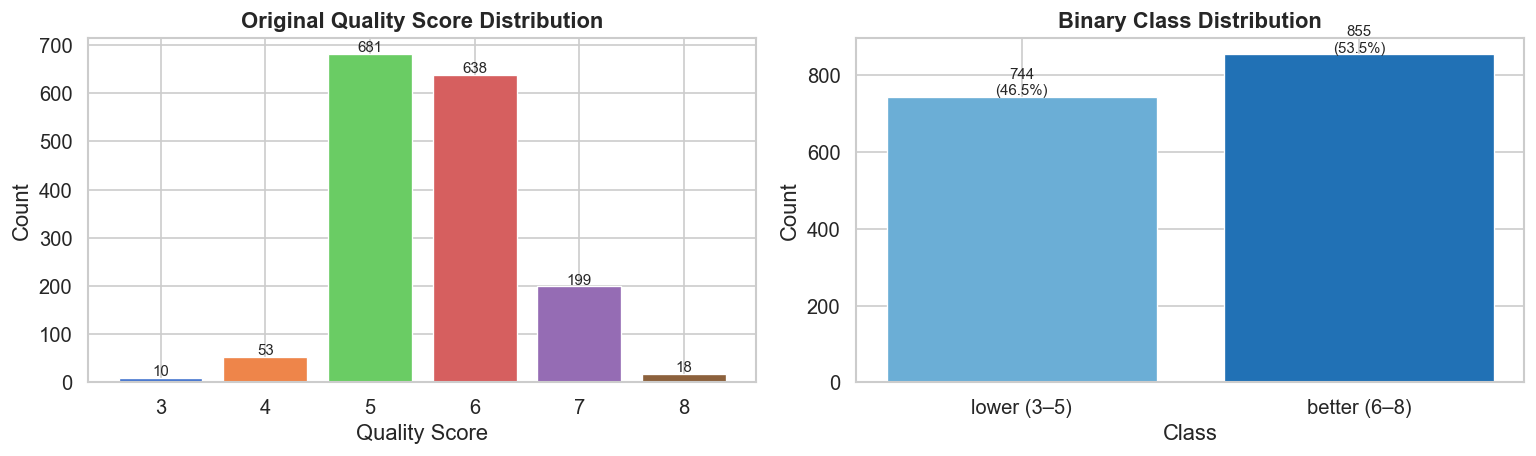

Binary class breakdown:
  lower (3–5): 744 samples (46.5%)
  better (6–8): 855 samples (53.5%)

→ Class ratio is ~46.5 : 53.5 — well-balanced, no resampling needed.


In [65]:
# ── Original quality distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

quality_counts = df['quality'].value_counts().sort_index()
axes[0].bar(quality_counts.index, quality_counts.values,
            color=sns.color_palette('muted'), edgecolor='white', linewidth=0.8)
axes[0].set_title('Original Quality Score Distribution', fontweight='bold')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Count')
for i, (score, count) in enumerate(quality_counts.items()):
    axes[0].text(score, count + 5, str(count), ha='center', fontsize=9)

# ── Binary encoding ───────────────────────────────────────────────────────────
df['quality_binary'] = (df['quality'] >= 6).astype(int)   # 0=lower, 1=better
label_map = {0: 'lower (3–5)', 1: 'better (6–8)'}

binary_counts = df['quality_binary'].value_counts().sort_index()
colors = ['#6baed6', '#2171b5']
axes[1].bar([label_map[k] for k in binary_counts.index], binary_counts.values,
            color=colors, edgecolor='white', linewidth=0.8)
axes[1].set_title('Binary Class Distribution', fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
total = binary_counts.sum()
for i, (label, count) in enumerate(zip([label_map[k] for k in binary_counts.index],
                                        binary_counts.values)):
    axes[1].text(i, count + 5, f'{count}\n({count/total*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('Binary class breakdown:')
for k, v in binary_counts.items():
    print(f'  {label_map[k]}: {v} samples ({v/total*100:.1f}%)')
print('\n→ Class ratio is ~46.5 : 53.5 — well-balanced, no resampling needed.')

### 3.3 Univariate Distributions — Each Feature

Histogram + KDE for all 11 input features to assess skewness, range, and potential outliers.

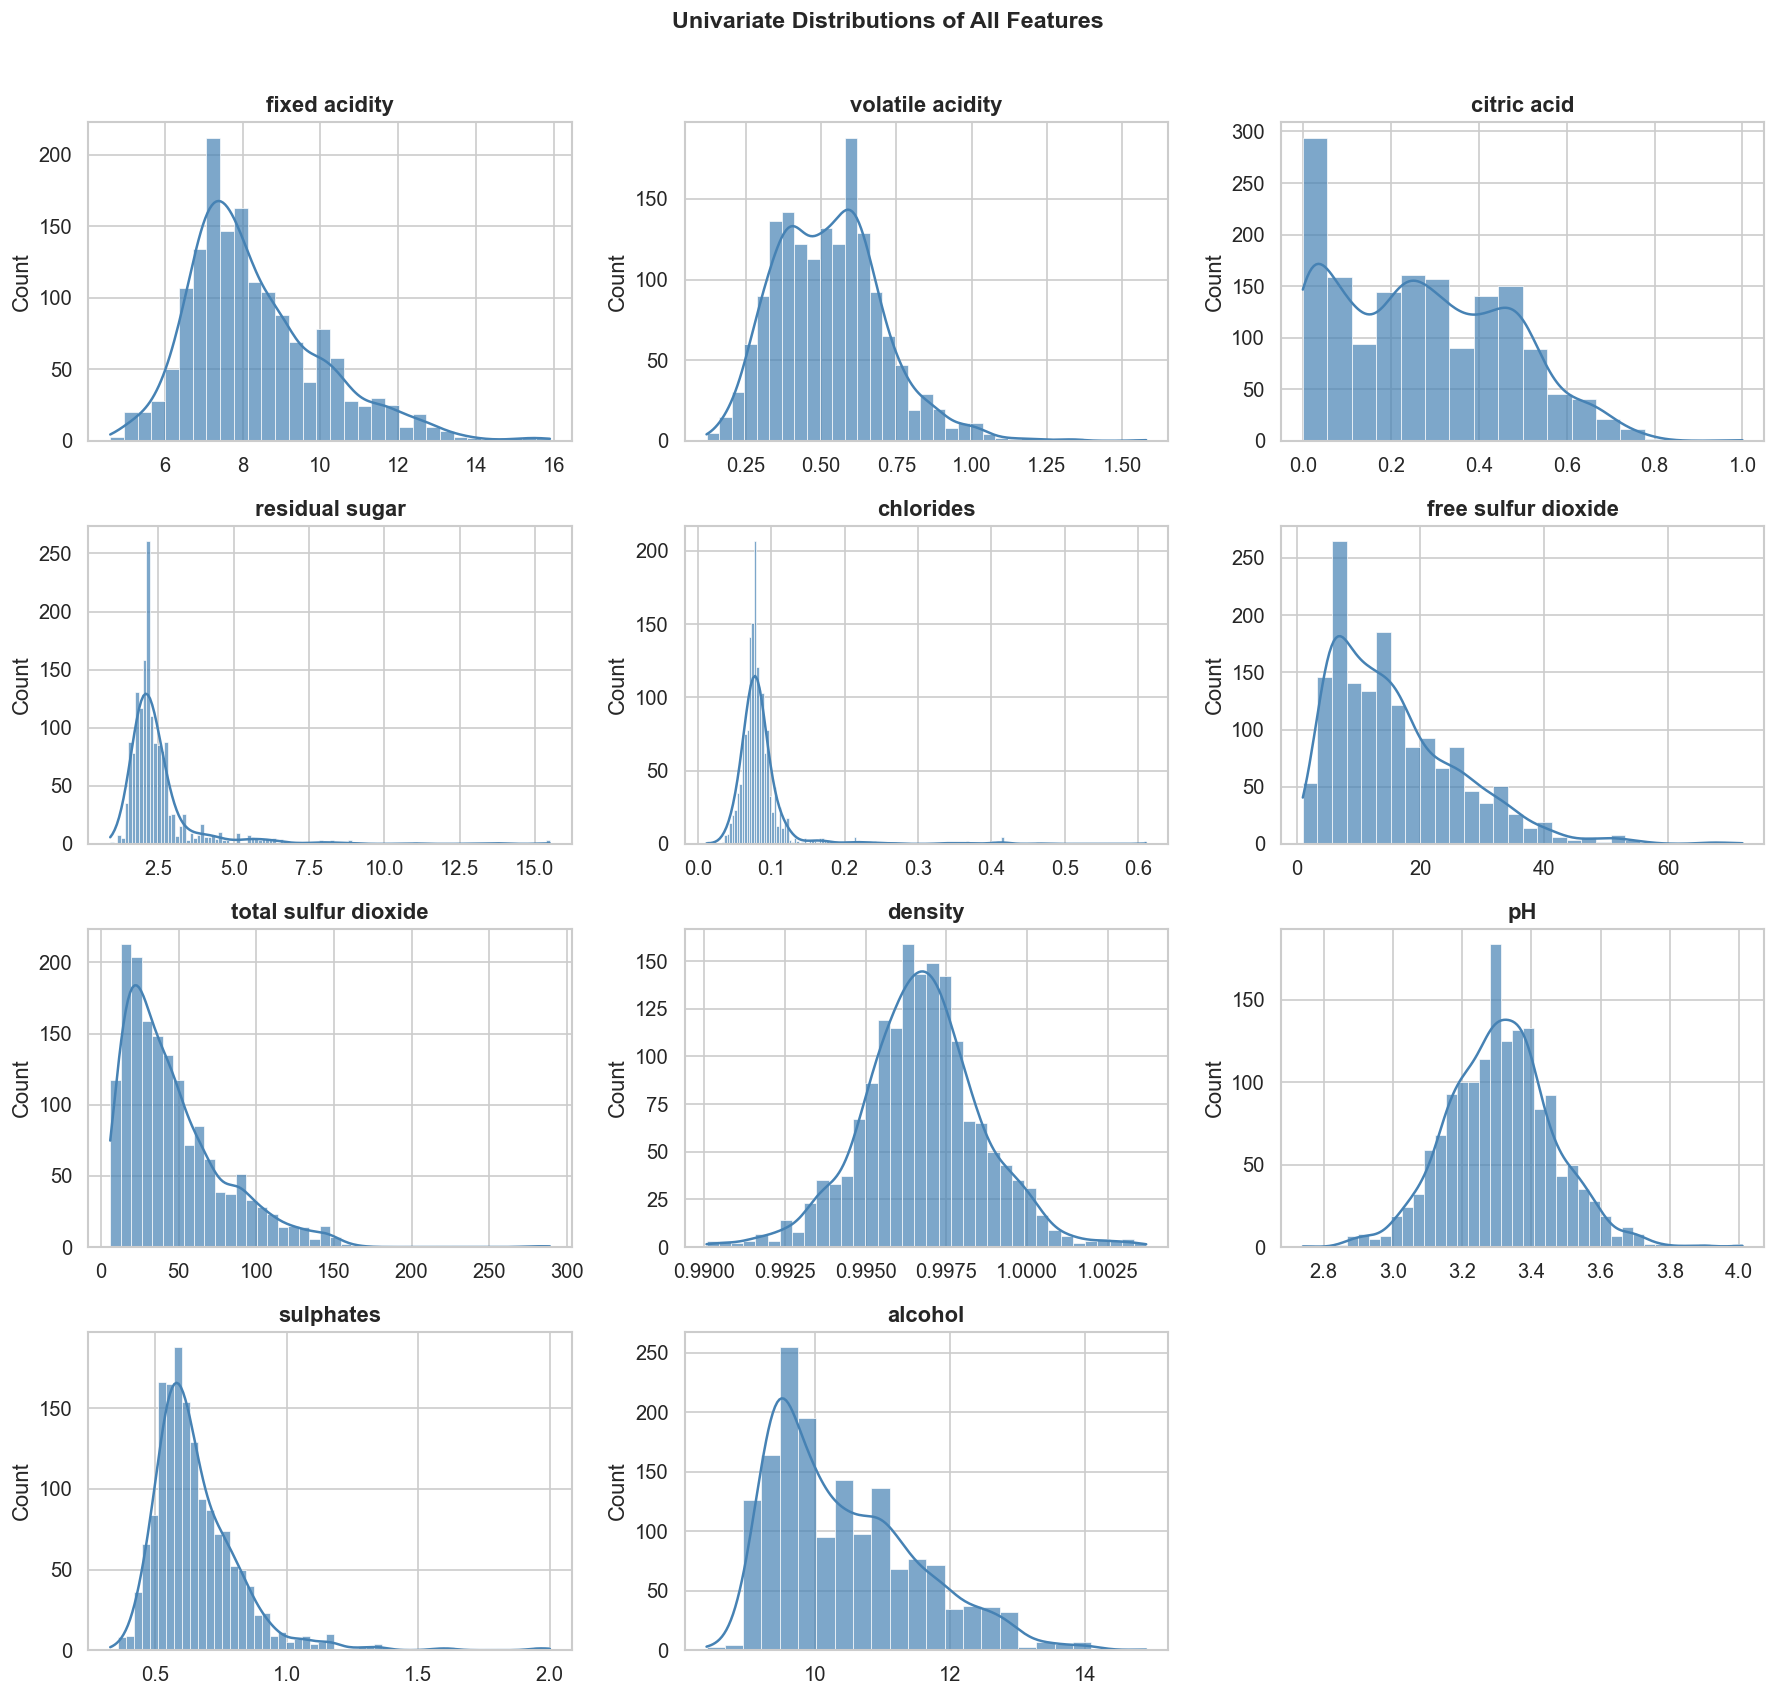

In [66]:
feature_cols = [c for c in df.columns if c not in ('quality', 'quality_binary')]

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', edgecolor='white',
                 linewidth=0.4, alpha=0.7)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

# Hide the empty 12th subplot
axes[-1].set_visible(False)

fig.suptitle('Univariate Distributions of All Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Outlier Detection — Boxplots

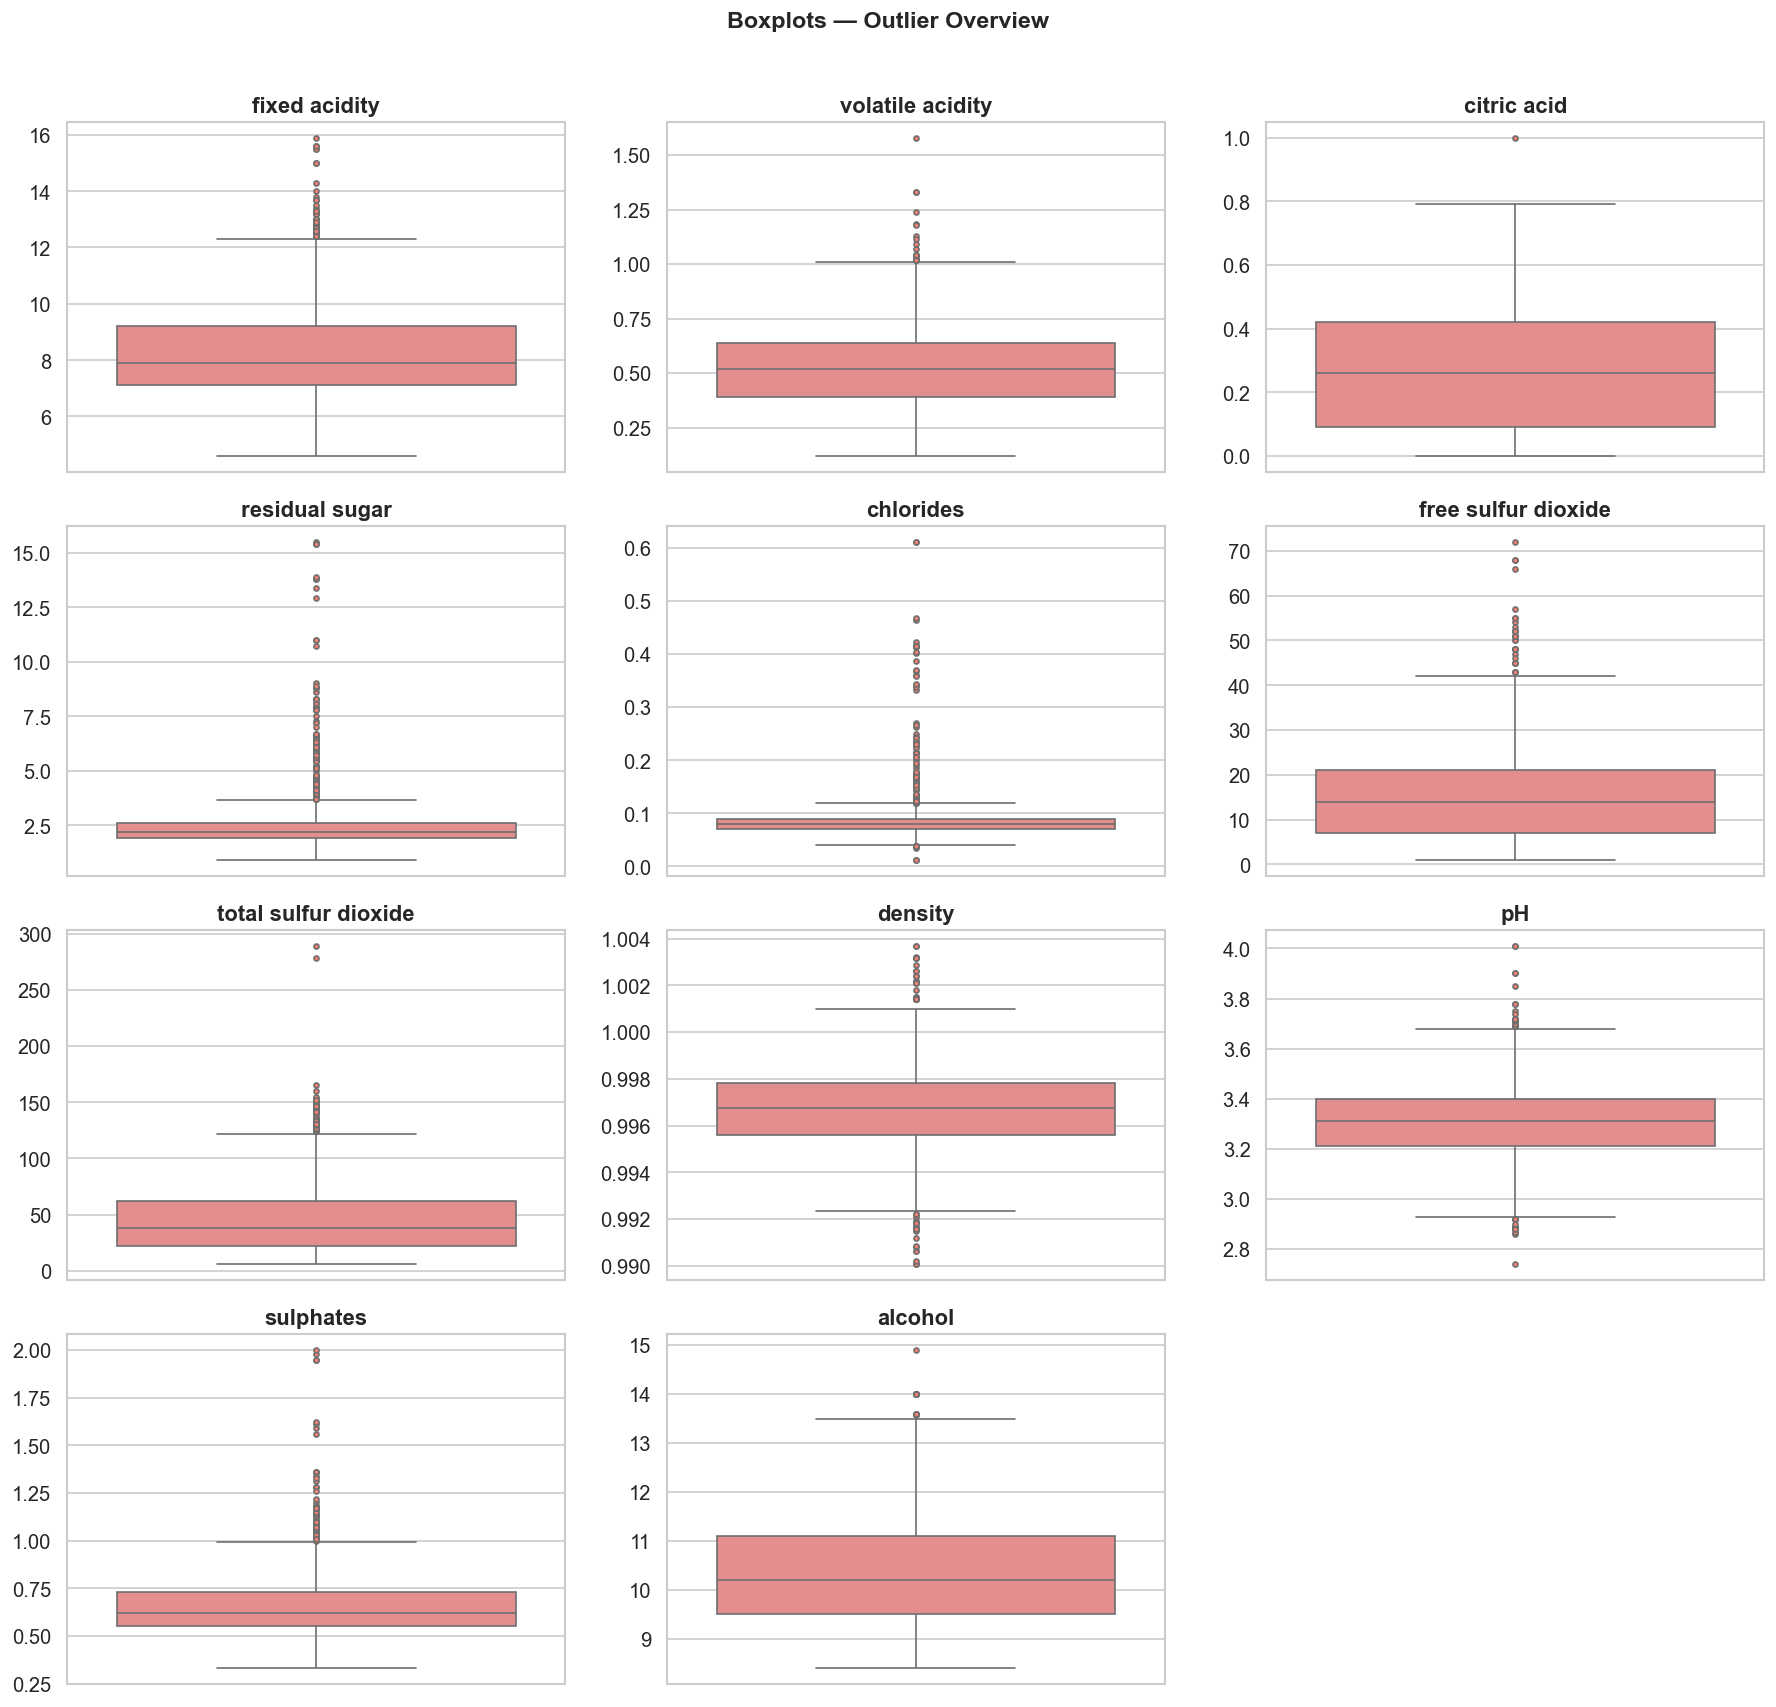

IQR outlier counts per feature:
  fixed acidity                 : 49 outliers (3.1%)
  volatile acidity              : 19 outliers (1.2%)
  citric acid                   : 1 outliers (0.1%)
  residual sugar                : 155 outliers (9.7%)
  chlorides                     : 112 outliers (7.0%)
  free sulfur dioxide           : 30 outliers (1.9%)
  total sulfur dioxide          : 55 outliers (3.4%)
  density                       : 45 outliers (2.8%)
  pH                            : 35 outliers (2.2%)
  sulphates                     : 59 outliers (3.7%)
  alcohol                       : 13 outliers (0.8%)


In [67]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral', flierprops=dict(
        marker='o', markerfacecolor='salmon', markersize=3, linestyle='none'))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('')

axes[-1].set_visible(False)

fig.suptitle('Boxplots — Outlier Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Count IQR outliers per feature for a quick report
print('IQR outlier counts per feature:')
for col in feature_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f'  {col:<30}: {n_out} outliers ({n_out/len(df)*100:.1f}%)')

### 3.5 Feature vs Target — Bivariate Analysis

Boxplots grouped by binary label reveal which features discriminate between **lower** and **better** quality wines.

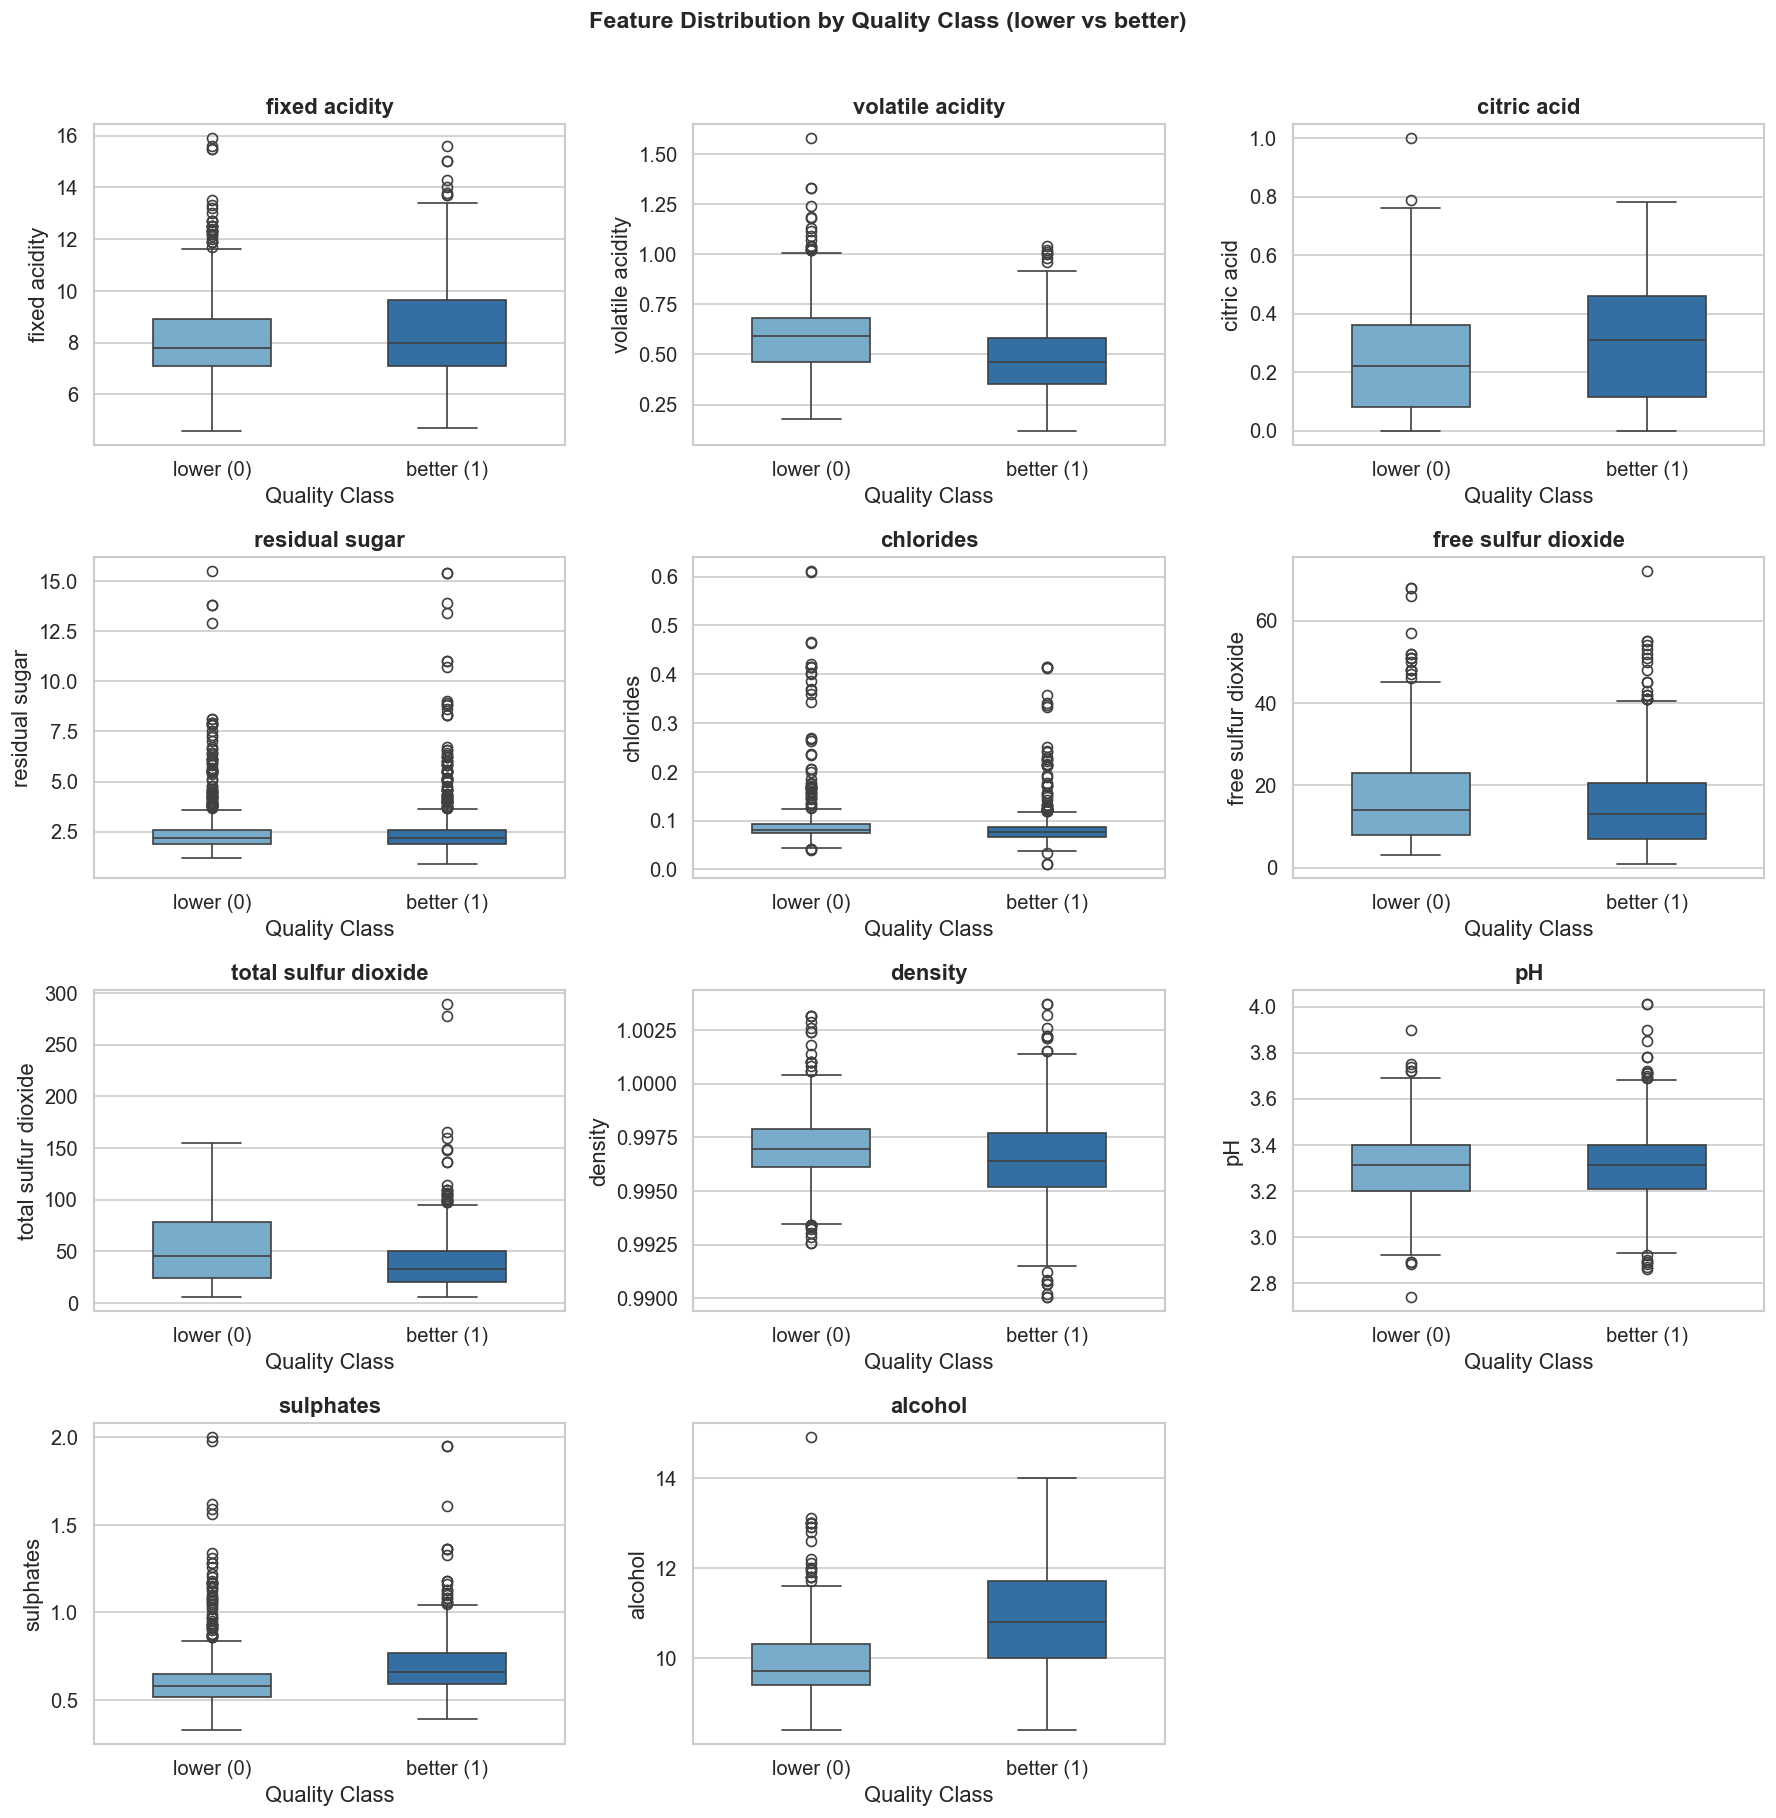

In [68]:
fig, axes = plt.subplots(4, 3, figsize=(15, 15))
axes = axes.flatten()

# Newer seaborn versions cast x values to strings, so palette keys must match
df['quality_binary_str'] = df['quality_binary'].astype(str)
palette = {'0': '#6baed6', '1': '#2171b5'}
tick_labels = ['lower (0)', 'better (1)']

for i, col in enumerate(feature_cols):
    sns.boxplot(
        x='quality_binary_str', y=col, data=df,
        palette=palette, order=['0', '1'],
        ax=axes[i], width=0.5
    )
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Quality Class')
    axes[i].set_xticklabels(tick_labels)

axes[-1].set_visible(False)

fig.suptitle('Feature Distribution by Quality Class (lower vs better)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


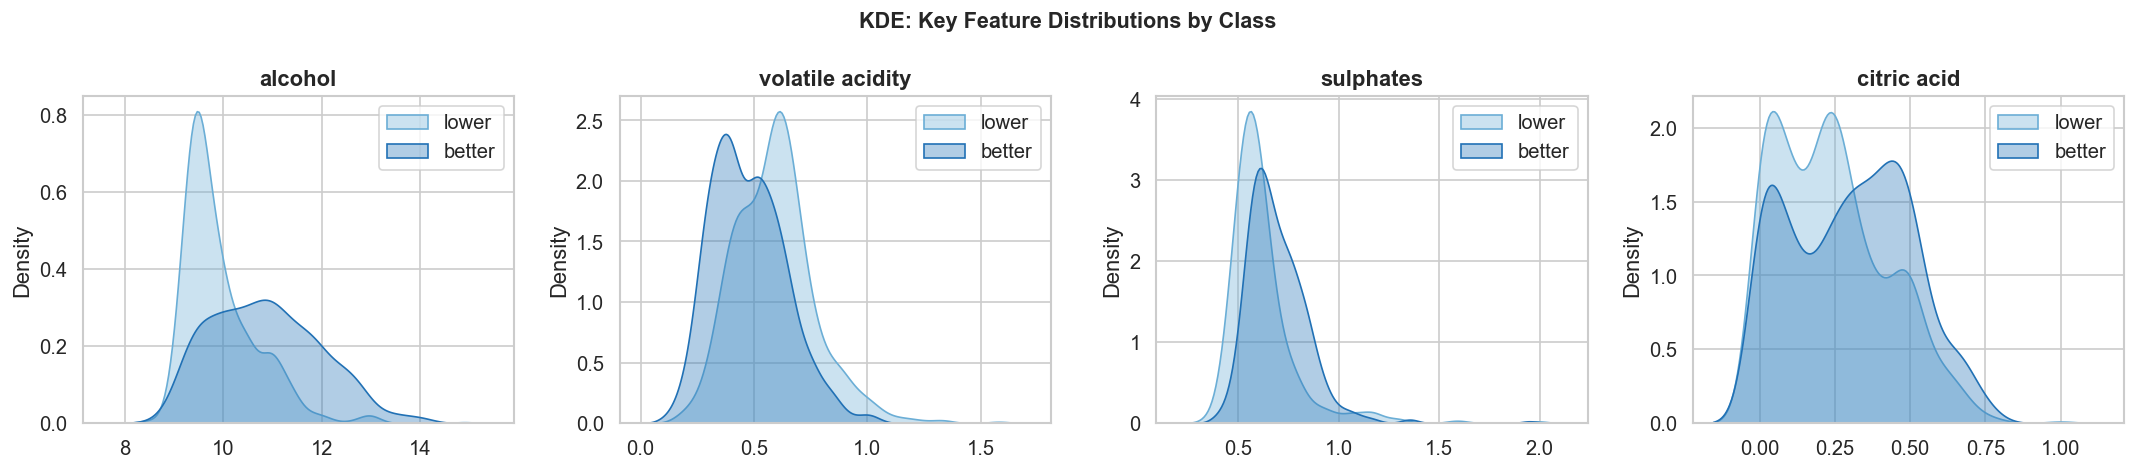

In [69]:
# KDE density overlay for the 4 most informative features
key_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, key_features):
    for label, color, name in zip([0, 1], ['#6baed6', '#2171b5'],
                                   ['lower', 'better']):
        subset = df[df['quality_binary'] == label][col]
        sns.kdeplot(subset, ax=ax, color=color, fill=True, alpha=0.35, label=name)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.legend()

fig.suptitle('KDE: Key Feature Distributions by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 Feature Correlation Analysis

Pearson correlation matrix reveals:
- **Feature–target** correlations (rightmost column / bottom row)
- **Feature–feature** multicollinearity (e.g., `free sulfur dioxide` vs `total sulfur dioxide`)

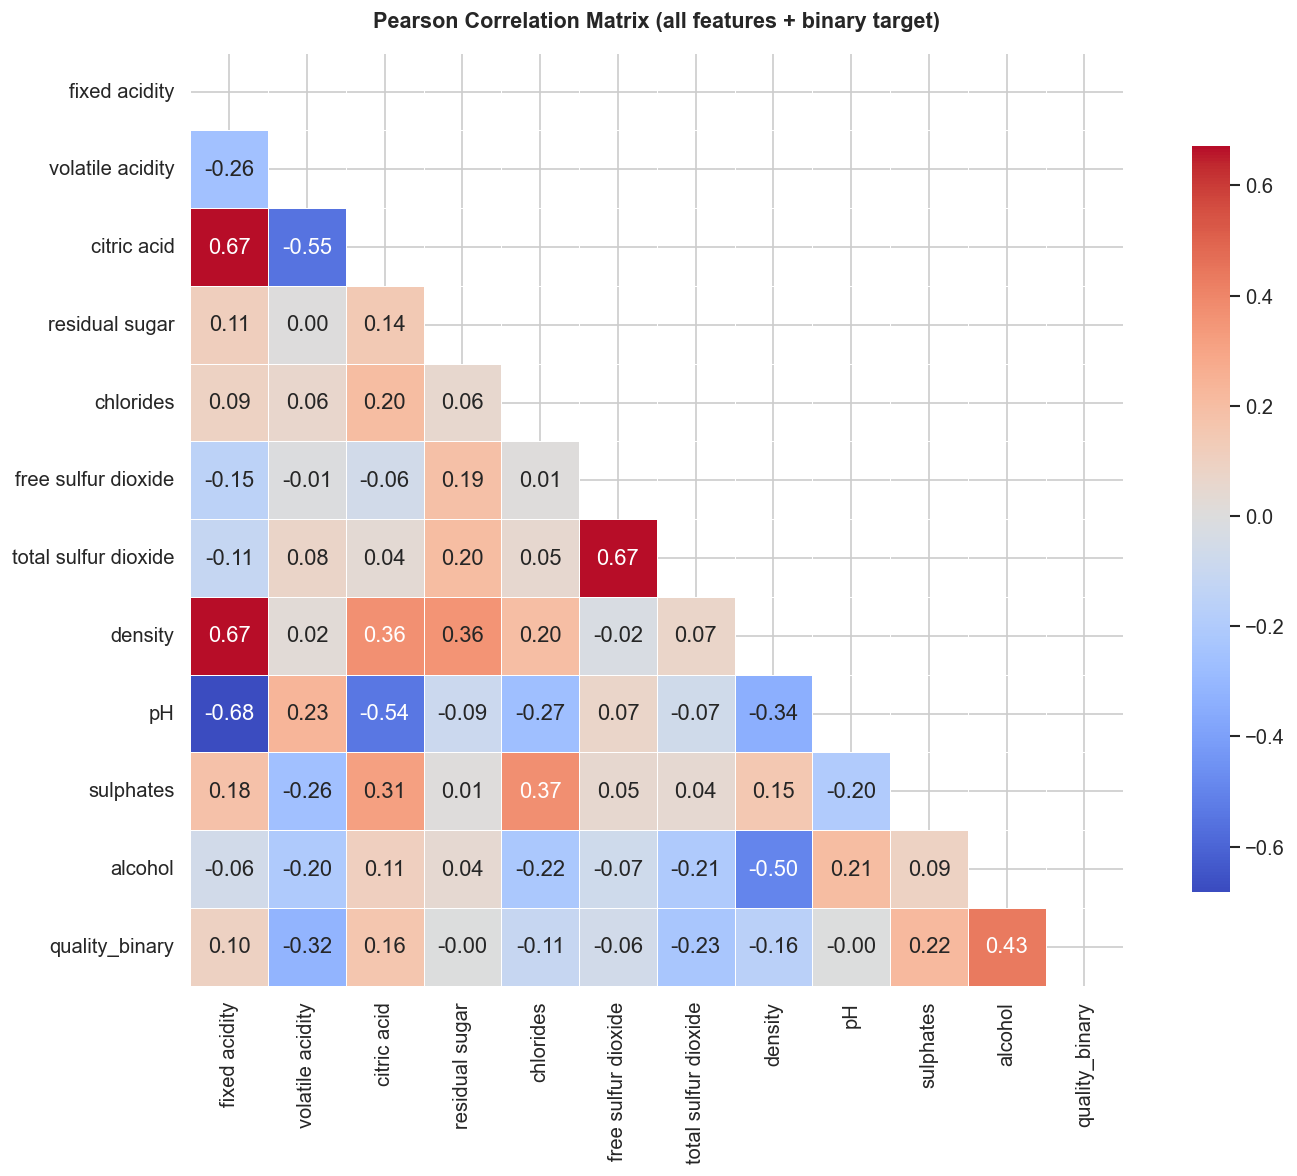


Correlation with target (quality_binary):
alcohol                 0.434751
sulphates               0.218072
citric acid             0.159129
fixed acidity           0.095093
residual sugar         -0.002160
pH                     -0.003264
free sulfur dioxide    -0.061757
chlorides              -0.109494
density                -0.159110
total sulfur dioxide   -0.231963
volatile acidity       -0.321441


In [70]:
# Include the binary label for a combined view
corr_df = df[feature_cols + ['quality_binary']].copy()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # hide upper triangle

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, square=True, cbar_kws={'shrink': 0.8}
)
ax.set_title('Pearson Correlation Matrix (all features + binary target)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Feature-to-target correlations sorted
target_corr = corr_matrix['quality_binary'][feature_cols].sort_values(ascending=False)
print('\nCorrelation with target (quality_binary):')
print(target_corr.to_string())

---
## 4. Feature Selection

We apply **four complementary methods** to rank feature importance:

| Method | Type | Relies on Model? |
|---|---|---|
| Pearson Correlation | Filter | No |
| ANOVA F-test | Filter | No |
| Lasso (L1 Logistic) | Embedded | Yes (LR) |
| Random Forest Importance | Embedded | Yes (RF) |

### 4.1 Prepare Features & Labels

In [71]:
X = df[feature_cols].copy()
y = df['quality_binary'].copy()

# StandardScaler for methods that are scale-sensitive (Pearson, Lasso)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

print(f'Features: {X.shape[1]}  |  Samples: {X.shape[0]}')
print(f'Class balance — lower: {(y==0).sum()}  better: {(y==1).sum()}')

Features: 11  |  Samples: 1599
Class balance — lower: 744  better: 855


### 4.2 Filter Method 1 — Pearson Correlation with Target

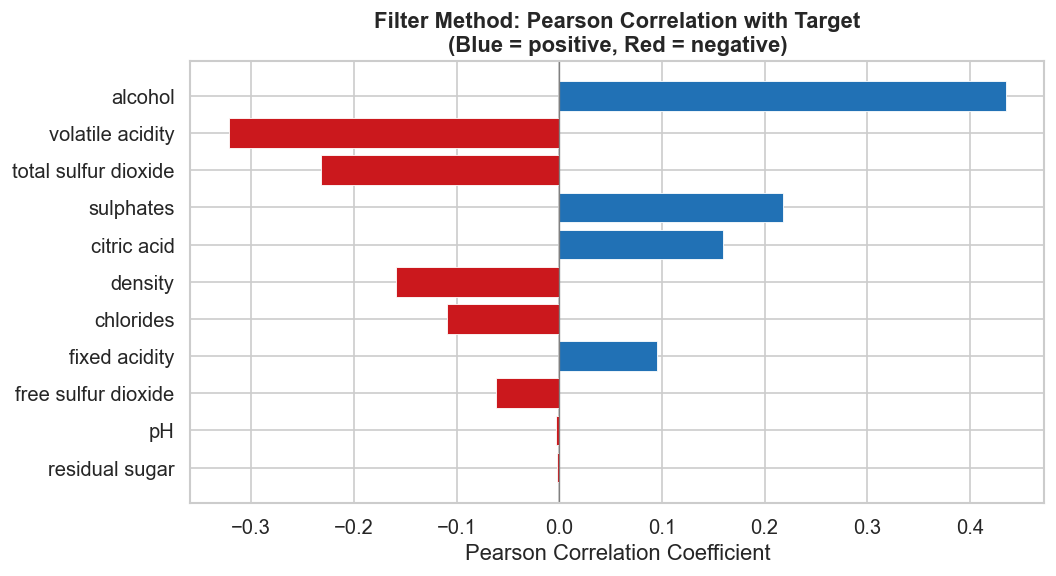


Pearson |correlation| ranking:
  Rank  1  alcohol                       : +0.4348
  Rank  2  volatile acidity              : -0.3214
  Rank  3  total sulfur dioxide          : -0.2320
  Rank  4  sulphates                     : +0.2181
  Rank  5  citric acid                   : +0.1591
  Rank  6  density                       : -0.1591
  Rank  7  chlorides                     : -0.1095
  Rank  8  fixed acidity                 : +0.0951
  Rank  9  free sulfur dioxide           : -0.0618
  Rank 10  pH                            : -0.0033
  Rank 11  residual sugar                : -0.0022


In [72]:
# Pearson correlation of each feature with the binary target
pearson_corr = X_scaled.corrwith(y).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2171b5' if v > 0 else '#cb181d' for v in pearson_corr.values]
ax.barh(pearson_corr.index[::-1], pearson_corr.values[::-1], color=colors[::-1],
        edgecolor='white', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlabel('Pearson Correlation Coefficient')
ax.set_title('Filter Method: Pearson Correlation with Target\n(Blue = positive, Red = negative)',
             fontweight='bold')
plt.tight_layout()
plt.show()

pearson_rank = pearson_corr.abs().rank(ascending=False).astype(int)
print('\nPearson |correlation| ranking:')
for feat in pearson_corr.index:
    print(f'  Rank {pearson_rank[feat]:2d}  {feat:<30}: {pearson_corr[feat]:+.4f}')

### 4.3 Filter Method 2 — ANOVA F-test

Tests whether each feature's **mean differs significantly** between the lower and better classes.  
A high F-value (and low p-value) signals strong discriminative power.

ANOVA F-test Results:
                   Feature     F-value       p-value  Significant (p<0.05)
Rank                                                                      
1                  alcohol  372.194765  1.023980e-74                  True
2         volatile acidity  184.022796  9.336621e-40                  True
3     total sulfur dioxide   90.816016  5.623796e-21                  True
4                sulphates   79.737680  1.147929e-18                  True
5              citric acid   41.490123  1.563717e-10                  True
6                  density   41.479723  1.571846e-10                  True
7                chlorides   19.378659  1.143103e-05                  True
8            fixed acidity   14.573088  1.399766e-04                  True
9      free sulfur dioxide    6.114110  1.351417e-02                  True
10                      pH    0.017014  8.962367e-01                 False
11          residual sugar    0.007454  9.312092e-01                 False


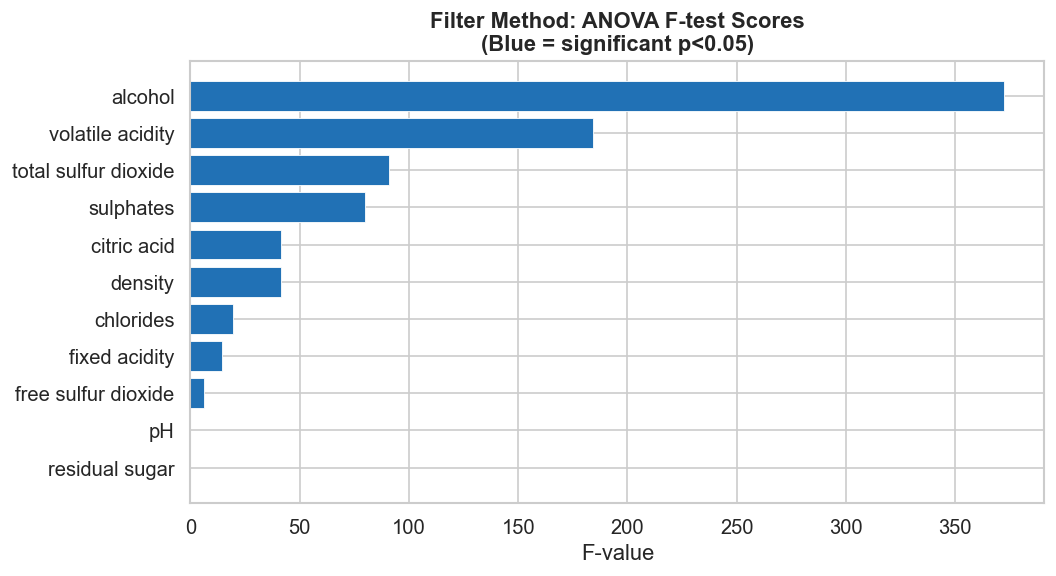

In [73]:
f_values, p_values = f_classif(X, y)

anova_df = pd.DataFrame({
    'Feature': feature_cols,
    'F-value': f_values,
    'p-value': p_values
}).sort_values('F-value', ascending=False).reset_index(drop=True)
anova_df.index += 1   # rank starts at 1
anova_df.index.name = 'Rank'

# Significance flag
anova_df['Significant (p<0.05)'] = anova_df['p-value'] < 0.05

print('ANOVA F-test Results:')
print(anova_df.to_string())

# Plot F-values
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#2171b5' if p < 0.05 else '#bdbdbd' for p in anova_df['p-value']]
ax.barh(anova_df['Feature'][::-1], anova_df['F-value'][::-1],
        color=bar_colors[::-1], edgecolor='white', linewidth=0.5)
ax.set_xlabel('F-value')
ax.set_title('Filter Method: ANOVA F-test Scores\n(Blue = significant p<0.05)',
             fontweight='bold')
plt.tight_layout()
plt.show()

### 4.4 Embedded Method 1 — Lasso (L1) Logistic Regression

L1 regularisation drives unimportant feature coefficients to zero, performing **automatic feature selection**.  
Standardisation is required so coefficients are comparable.

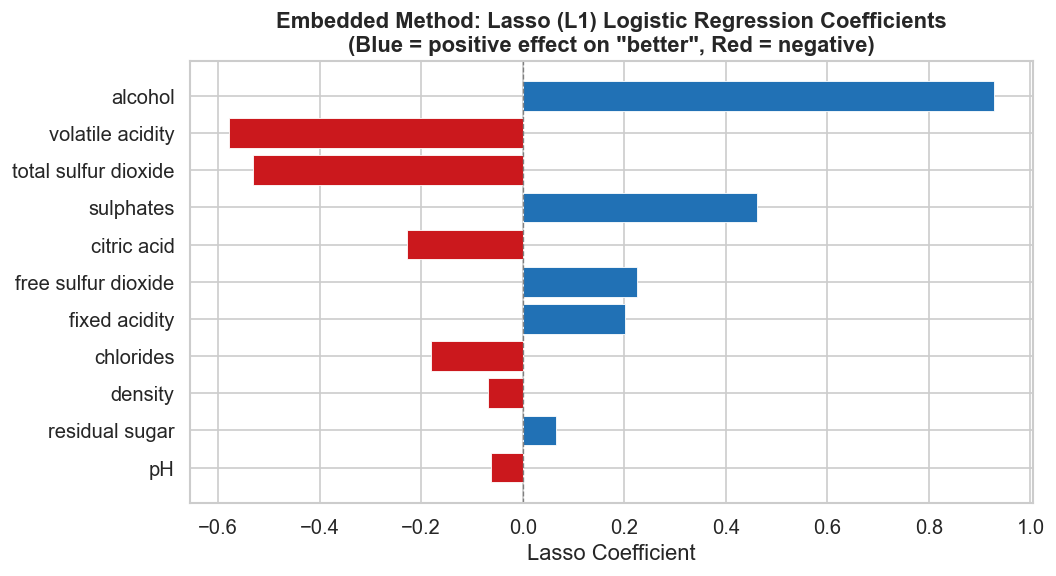

Features zeroed out by Lasso: None

Lasso coefficients (sorted by |magnitude|):
alcohol                 0.929262
volatile acidity       -0.579203
total sulfur dioxide   -0.530549
sulphates               0.462274
citric acid            -0.228045
free sulfur dioxide     0.224189
fixed acidity           0.202281
chlorides              -0.181479
density                -0.068055
residual sugar          0.064924
pH                     -0.063203


In [74]:
# Fit Lasso LR on the entire scaled dataset to get coefficient-based importance
lasso_lr = LogisticRegression(
    penalty='l1', solver='liblinear', C=1.0, max_iter=1000, random_state=42
)
lasso_lr.fit(X_scaled, y)

coef_series = pd.Series(lasso_lr.coef_[0], index=feature_cols).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#2171b5' if v > 0 else '#cb181d' for v in coef_series.values]
ax.barh(coef_series.index[::-1], coef_series.values[::-1],
        color=bar_colors[::-1], edgecolor='white', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Lasso Coefficient')
ax.set_title('Embedded Method: Lasso (L1) Logistic Regression Coefficients\n'
             '(Blue = positive effect on "better", Red = negative)',
             fontweight='bold')
plt.tight_layout()
plt.show()

zero_coef = coef_series[coef_series == 0]
print(f'Features zeroed out by Lasso: {list(zero_coef.index) if len(zero_coef) else "None"}')
print('\nLasso coefficients (sorted by |magnitude|):')
print(coef_series.to_string())

### 4.5 Embedded Method 2 — Random Forest Feature Importance

Gini-based importance from a Random Forest captures **non-linear and interaction effects** that Pearson correlation or Lasso may miss.

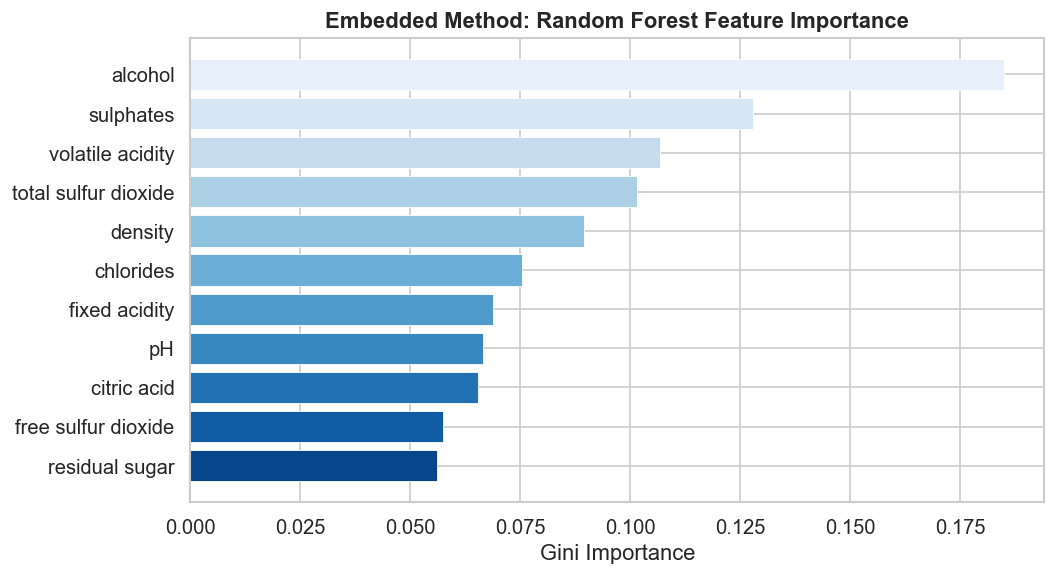

RF Feature Importance ranking:
  Rank  1  alcohol                       : 0.1849
  Rank  2  sulphates                     : 0.1280
  Rank  3  volatile acidity              : 0.1068
  Rank  4  total sulfur dioxide          : 0.1015
  Rank  5  density                       : 0.0894
  Rank  6  chlorides                     : 0.0753
  Rank  7  fixed acidity                 : 0.0687
  Rank  8  pH                            : 0.0665
  Rank  9  citric acid                   : 0.0654
  Rank 10  free sulfur dioxide           : 0.0575
  Rank 11  residual sugar                : 0.0560


In [75]:
rf_selector = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_selector.fit(X, y)   # trees don't need scaling

rf_importance = pd.Series(
    rf_selector.feature_importances_, index=feature_cols
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
palette_rf = sns.color_palette('Blues_r', len(feature_cols))
ax.barh(rf_importance.index[::-1], rf_importance.values[::-1],
        color=palette_rf, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Gini Importance')
ax.set_title('Embedded Method: Random Forest Feature Importance', fontweight='bold')
plt.tight_layout()
plt.show()

print('RF Feature Importance ranking:')
for rank, (feat, imp) in enumerate(rf_importance.items(), 1):
    print(f'  Rank {rank:2d}  {feat:<30}: {imp:.4f}')

### 4.6 Feature Selection Summary — Cross-Method Comparison

Aggregating ranks across all four methods identifies the most consistently important features.

Cross-Method Feature Ranking (lower = more important):
                      Pearson_rank  ANOVA_rank  Lasso_rank  RF_rank  Mean_rank
alcohol                          1           1           1        1       1.00
volatile acidity                 2           2           2        3       2.25
total sulfur dioxide             3           3           3        4       3.25
sulphates                        4           4           4        2       3.50
citric acid                      5           5           5        9       6.00
density                          6           6           9        5       6.50
chlorides                        7           7           8        6       7.00
fixed acidity                    8           8           7        7       7.50
free sulfur dioxide              9           9           6       10       8.50
pH                              10          10          11        8       9.75
residual sugar                  11          11          10       11      10.

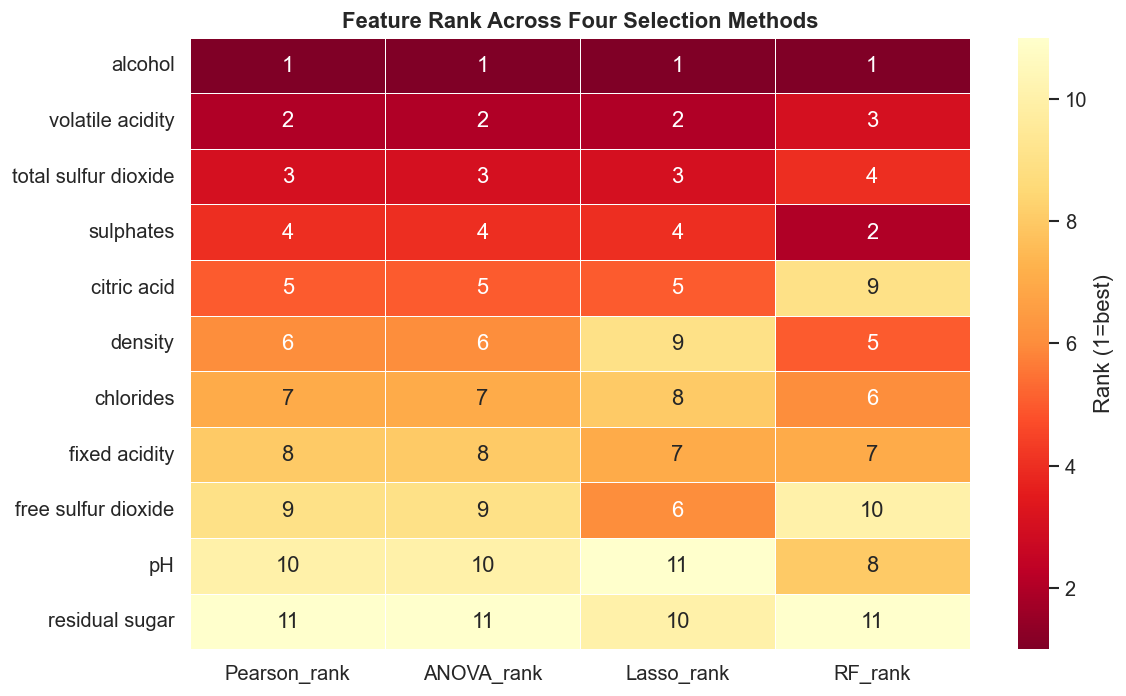


Selected top-6 features: ['alcohol', 'volatile acidity', 'total sulfur dioxide', 'sulphates', 'citric acid', 'density']


In [76]:
# Build a rank table across all four methods (rank 1 = most important)
rank_table = pd.DataFrame(index=feature_cols)

rank_table['Pearson_rank']  = pearson_corr.abs().rank(ascending=False).astype(int)
rank_table['ANOVA_rank']    = anova_df.set_index('Feature')['F-value'].rank(ascending=False).astype(int)
rank_table['Lasso_rank']    = coef_series.abs().rank(ascending=False).astype(int)
rank_table['RF_rank']       = rf_importance.rank(ascending=False).astype(int)
rank_table['Mean_rank']     = rank_table.mean(axis=1).round(2)
rank_table = rank_table.sort_values('Mean_rank')

print('Cross-Method Feature Ranking (lower = more important):')
print(rank_table.to_string())

# Heatmap visualisation of ranks
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    rank_table[['Pearson_rank', 'ANOVA_rank', 'Lasso_rank', 'RF_rank']],
    annot=True, fmt='d', cmap='YlOrRd_r', linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Rank (1=best)'}
)
ax.set_title('Feature Rank Across Four Selection Methods', fontweight='bold')
plt.tight_layout()
plt.show()

# Select top-6 features (consistently top-ranked across methods)
top_features = rank_table.head(6).index.tolist()
print(f'\nSelected top-6 features: {top_features}')

---
## 5. Data Splitting

We split **before** any scaling to prevent data leakage — the scaler must only learn statistics from the training set, then apply those same statistics to the test set.

An 80/20 stratified split preserves the class ratio in both subsets.

In [77]:
# ── Full feature set (all 11) ────────────────────────────────────────────────
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ── Selected feature set (top-6 from cross-method ranking) ───────────────────
# top_features was defined at the end of Section 4.6
X_sel = X[top_features]
X_train_sel, X_test_sel, _, _ = train_test_split(
    X_sel, y, test_size=0.20, random_state=42, stratify=y
)

# Convenience aliases — models default to full features
X_train, X_test = X_train_full, X_test_full

print(f'Full feature set  : {X_train_full.shape[1]} features | '
      f'{X_train_full.shape[0]} train / {X_test_full.shape[0]} test samples')
print(f'Selected feature set: {X_train_sel.shape[1]} features | '
      f'{X_train_sel.shape[0]} train / {X_test_sel.shape[0]} test samples')
print(f'Selected features: {top_features}')
print(f'\nClass balance — lower: {(y_train==0).sum()} | better: {(y_train==1).sum()}')


Full feature set  : 11 features | 1279 train / 320 test samples
Selected feature set: 6 features | 1279 train / 320 test samples
Selected features: ['alcohol', 'volatile acidity', 'total sulfur dioxide', 'sulphates', 'citric acid', 'density']

Class balance — lower: 595 | better: 684


---
## 6. Feature Scaling & Normalization

### Why scaling matters

The 11 features operate on very different numeric scales:
- `total sulfur dioxide` ranges up to ~289
- `alcohol` ranges ~8–15
- `residual sugar` ranges ~1–16

Without scaling, models that rely on distances or gradient descent (like Logistic Regression) will be dominated by high-magnitude features, producing biased coefficients and slower convergence.

### Scaling decision per model

| Model | Needs Scaling? | Reason |
|---|---|---|
| Logistic Regression | **Yes** | Gradient-based optimisation; coefficients are scale-dependent |
| Decision Tree | **No** | Splits on thresholds — monotonic transforms don't change split quality |
| Random Forest | **No** | Ensemble of trees; same reasoning as above |

> **Important:** `StandardScaler` is fit **only on the training set** and applied to both train and test sets. Fitting on the full dataset would leak test-set statistics into the model — a form of data leakage.

### 6.1 Feature Ranges Before Scaling

In [78]:
# Summary statistics of raw features — shows the scale disparity
raw_stats = X_train_full.describe().T[['min', 'max', 'mean', 'std']].round(3)
raw_stats.columns = ['Min', 'Max', 'Mean', 'Std']
raw_stats['Range'] = (raw_stats['Max'] - raw_stats['Min']).round(3)
raw_stats = raw_stats.sort_values('Range', ascending=False)

print('Raw feature statistics (training set):')
display(raw_stats.style
        .background_gradient(cmap='YlOrRd', subset=['Range'])
        .format(precision=3))


Raw feature statistics (training set):


,Min,Max,Mean,Std,Range
total sulfur dioxide,6.000,289.000,46.427,33.193,283.000
free sulfur dioxide,1.000,72.000,15.846,10.221,71.000
residual sugar,0.900,15.500,2.540,1.382,14.600
fixed acidity,4.600,15.900,8.338,1.757,11.300
alcohol,8.400,14.900,10.437,1.072,6.500
sulphates,0.370,1.980,0.658,0.165,1.610
volatile acidity,0.120,1.580,0.526,0.179,1.460
pH,2.860,4.010,3.312,0.154,1.150
citric acid,0.000,0.790,0.273,0.194,0.790
chlorides,0.012,0.611,0.087,0.046,0.599


### 6.2 Applying StandardScaler

`StandardScaler` transforms each feature to have **mean = 0** and **std = 1**:

$$z = \\frac{x - \\mu_{\\text{train}}}{\\sigma_{\\text{train}}}$$

The scaler is fit on training data only, then applied to both train and test.

In [79]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training set ONLY — then transform both splits
X_train_full_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_full),
    columns=feature_cols, index=X_train_full.index
)
X_test_full_scaled = pd.DataFrame(
    scaler.transform(X_test_full),   # transform only — no re-fitting
    columns=feature_cols, index=X_test_full.index
)

# Same for selected feature set
scaler_sel = StandardScaler()
X_train_sel_scaled = pd.DataFrame(
    scaler_sel.fit_transform(X_train_sel),
    columns=top_features, index=X_train_sel.index
)
X_test_sel_scaled = pd.DataFrame(
    scaler_sel.transform(X_test_sel),
    columns=top_features, index=X_test_sel.index
)

# Verify: mean ≈ 0, std ≈ 1 on training set
scaled_stats = X_train_full_scaled.describe().T[['mean', 'std']].round(4)
print('After scaling — training set (should be mean≈0, std≈1):')
display(scaled_stats.style.format(precision=4))


After scaling — training set (should be mean≈0, std≈1):


,mean,std
fixed acidity,0.0000,1.0004
volatile acidity,-0.0000,1.0004
citric acid,-0.0000,1.0004
residual sugar,0.0000,1.0004
chlorides,-0.0000,1.0004
free sulfur dioxide,-0.0000,1.0004
total sulfur dioxide,-0.0000,1.0004
density,0.0000,1.0004
pH,-0.0000,1.0004
sulphates,0.0000,1.0004


### 6.3 Before vs After Scaling — Visual Comparison

Comparing distributions of selected features before and after `StandardScaler`.

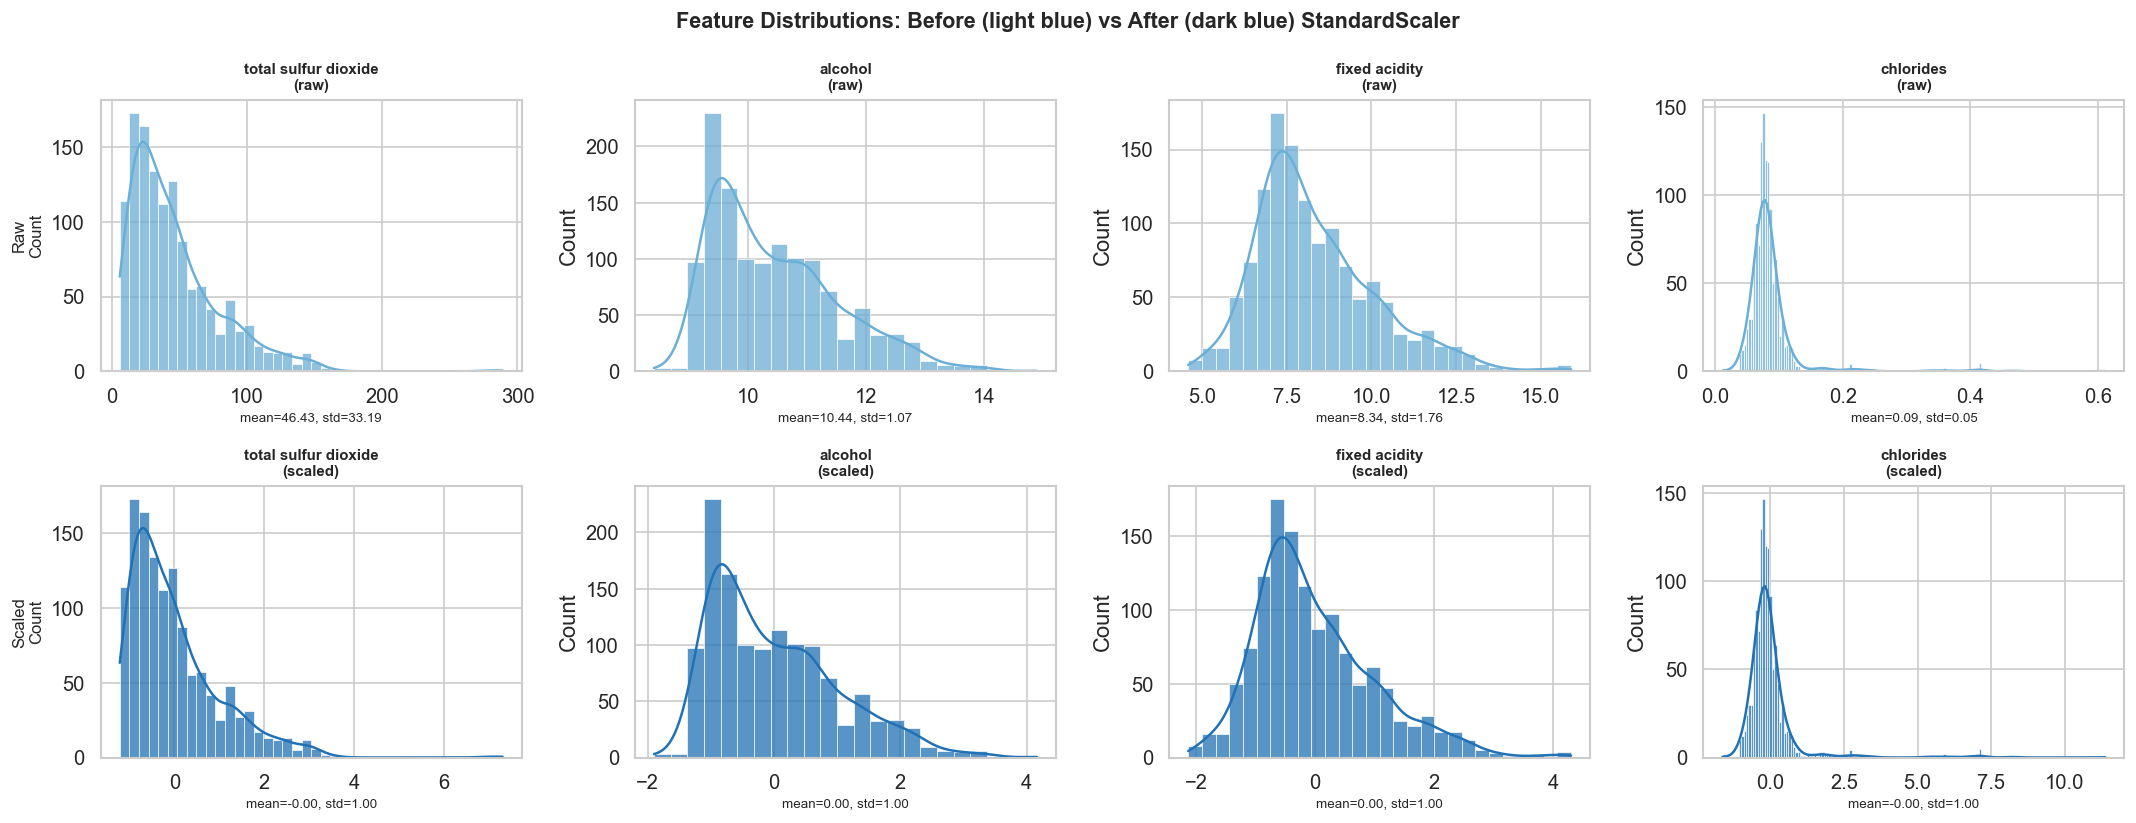

Key observation: shape is preserved — StandardScaler only shifts and rescales, it does NOT change the distribution shape or fix skewness.


In [80]:
# Show before/after for 4 features with very different original scales
demo_features = ['total sulfur dioxide', 'alcohol', 'fixed acidity', 'chlorides']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))

for col, ax_raw, ax_scaled in zip(demo_features, axes[0], axes[1]):
    # Raw
    sns.histplot(X_train_full[col], kde=True, ax=ax_raw,
                 color='#6baed6', edgecolor='white', linewidth=0.4, alpha=0.75)
    ax_raw.set_title(f'{col}\n(raw)', fontweight='bold', fontsize=9)
    ax_raw.set_xlabel(f'mean={X_train_full[col].mean():.2f}, '
                      f'std={X_train_full[col].std():.2f}', fontsize=8)
    ax_raw.set_ylabel('Count')

    # Scaled
    sns.histplot(X_train_full_scaled[col], kde=True, ax=ax_scaled,
                 color='#2171b5', edgecolor='white', linewidth=0.4, alpha=0.75)
    ax_scaled.set_title(f'{col}\n(scaled)', fontweight='bold', fontsize=9)
    ax_scaled.set_xlabel(f'mean={X_train_full_scaled[col].mean():.2f}, '
                         f'std={X_train_full_scaled[col].std():.2f}', fontsize=8)
    ax_scaled.set_ylabel('Count')

axes[0][0].set_ylabel('Raw\nCount', fontsize=10)
axes[1][0].set_ylabel('Scaled\nCount', fontsize=10)

fig.suptitle('Feature Distributions: Before (light blue) vs After (dark blue) StandardScaler',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key observation: shape is preserved — StandardScaler only shifts and rescales,'
      ' it does NOT change the distribution shape or fix skewness.')


### 6.4 How Scaling is Applied in Modelling

To avoid any risk of leakage during cross-validation and GridSearchCV, **Logistic Regression is wrapped in a `Pipeline`** that includes the scaler as the first step. This guarantees the scaler is re-fit on each CV fold's training portion only.

```python
Pipeline([
    ('scaler', StandardScaler()),   # fit on train fold only
    ('lr', LogisticRegression(...))
])
```

Decision Tree and Random Forest receive the **raw (unscaled)** data directly — scaling would have no effect on their predictions.

---
## 7. Model 1 — Logistic Regression

A linear probabilistic classifier. Uses `StandardScaler` inside a `Pipeline` to avoid data leakage.

**Key hyperparameters tuned:** regularisation strength `C`, penalty type (`L1` / `L2`).

In [81]:
# ── Helper: train + evaluate a pipeline on full AND selected features ────────
def eval_pipeline(pipeline, X_tr_f, X_te_f, X_tr_s, X_te_s, y_tr, y_te, label):
    """Fit pipeline on full and selected feature sets; return prediction dicts."""
    results = {}
    for tag, X_tr, X_te in [('Full (11)', X_tr_f, X_te_f),
                             ('Selected (6)', X_tr_s, X_te_s)]:
        pipeline.fit(X_tr, y_tr)
        y_pred = pipeline.predict(X_te)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_f1 = cross_val_score(pipeline,
                                pd.concat([X_tr, X_te]),
                                pd.concat([y_tr, y_te]),
                                cv=cv, scoring='f1')
        results[tag] = {
            'y_pred':   y_pred,
            'Accuracy': accuracy_score(y_te, y_pred),
            'Precision': precision_score(y_te, y_pred),
            'Recall':   recall_score(y_te, y_pred),
            'F1':       f1_score(y_te, y_pred),
            'CV_F1_mean': cv_f1.mean(),
            'CV_F1_std':  cv_f1.std(),
        }
        print(f'  [{label} | {tag}]  '
              f'Acc={results[tag]["Accuracy"]:.4f}  '
              f'F1={results[tag]["F1"]:.4f}  '
              f'CV-F1={cv_f1.mean():.4f}±{cv_f1.std():.4f}')
    return results

# Storage for all models x feature-sets
all_results = {}

# ── Logistic Regression ───────────────────────────────────────────────────────
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                              max_iter=1000, random_state=42))
])

print('=== Logistic Regression ===')
all_results['Logistic Regression'] = eval_pipeline(
    lr_pipeline,
    X_train_full, X_test_full,
    X_train_sel,  X_test_sel,
    y_train, y_test, 'LR'
)

# Keep the full-feature predictions for the confusion matrix section
y_pred_lr = all_results['Logistic Regression']['Full (11)']['y_pred']
y_pred_lr_sel = all_results['Logistic Regression']['Selected (6)']['y_pred']

# Refit on full features for the classification report
lr_pipeline.fit(X_train_full, y_train)
print()
print(classification_report(y_test, y_pred_lr, target_names=['lower', 'better']))


=== Logistic Regression ===
  [LR | Full (11)]  Acc=0.7406  F1=0.7522  CV-F1=0.7534±0.0260
  [LR | Selected (6)]  Acc=0.7500  F1=0.7633  CV-F1=0.7563±0.0273

              precision    recall  f1-score   support

       lower       0.71      0.74      0.73       149
      better       0.77      0.74      0.75       171

    accuracy                           0.74       320
   macro avg       0.74      0.74      0.74       320
weighted avg       0.74      0.74      0.74       320



---
## 8. Model 2 — Decision Tree

A non-parametric classifier that learns axis-aligned split rules. Prone to overfitting without depth limits.  

**Key hyperparameters tuned:** `max_depth`, `min_samples_split`, `min_samples_leaf`.

In [82]:
# ── Decision Tree ─────────────────────────────────────────────────────────────
dt_clf = DecisionTreeClassifier(
    max_depth=5, min_samples_split=20,
    min_samples_leaf=10, criterion='gini', random_state=42
)

print('=== Decision Tree ===')
all_results['Decision Tree'] = eval_pipeline(
    dt_clf,
    X_train_full, X_test_full,
    X_train_sel,  X_test_sel,
    y_train, y_test, 'DT'
)

y_pred_dt     = all_results['Decision Tree']['Full (11)']['y_pred']
y_pred_dt_sel = all_results['Decision Tree']['Selected (6)']['y_pred']

# Refit on full features for the tree plot
dt_clf.fit(X_train_full, y_train)
print()
print(classification_report(y_test, y_pred_dt, target_names=['lower', 'better']))


=== Decision Tree ===
  [DT | Full (11)]  Acc=0.7312  F1=0.7410  CV-F1=0.7235±0.0293
  [DT | Selected (6)]  Acc=0.7219  F1=0.7375  CV-F1=0.7443±0.0315

              precision    recall  f1-score   support

       lower       0.70      0.74      0.72       149
      better       0.76      0.72      0.74       171

    accuracy                           0.73       320
   macro avg       0.73      0.73      0.73       320
weighted avg       0.73      0.73      0.73       320



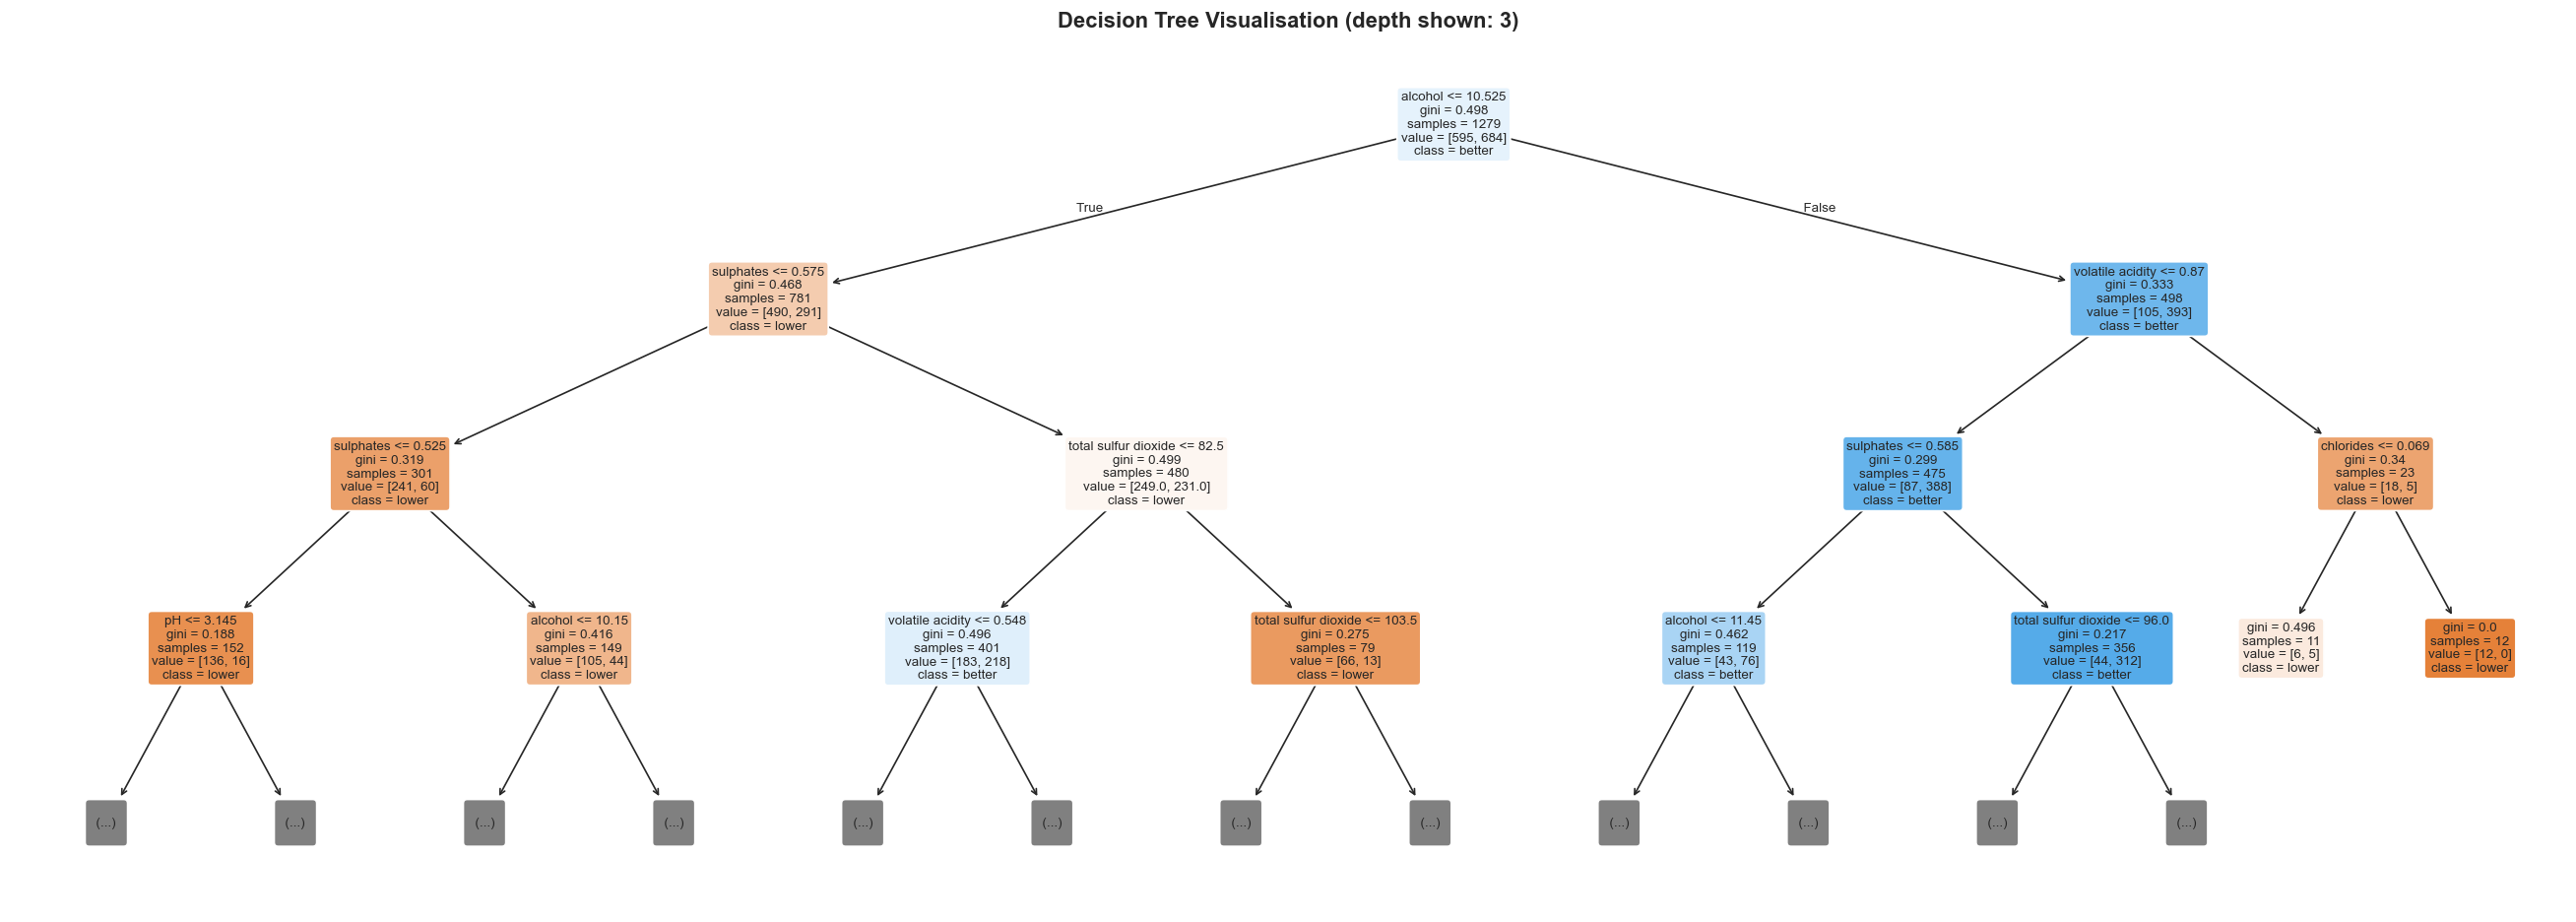

In [83]:
# Visualise the pruned tree (max depth 3 for readability)
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt_clf, feature_names=feature_cols, class_names=['lower', 'better'],
    filled=True, rounded=True, max_depth=3, ax=ax,
    fontsize=8
)
ax.set_title('Decision Tree Visualisation (depth shown: 3)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Model 3 — Random Forest

An ensemble of decision trees trained on bootstrap samples with random feature subsets.  
Reduces variance compared to a single tree and generally achieves the best performance on this dataset.

**Key hyperparameters tuned:** `n_estimators`, `max_depth`, `max_features`.

In [84]:
# ── Random Forest ─────────────────────────────────────────────────────────────
rf_clf = RandomForestClassifier(
    n_estimators=300, max_depth=10, max_features='sqrt',
    min_samples_leaf=5, random_state=42, n_jobs=-1
)

print('=== Random Forest ===')
all_results['Random Forest'] = eval_pipeline(
    rf_clf,
    X_train_full, X_test_full,
    X_train_sel,  X_test_sel,
    y_train, y_test, 'RF'
)

y_pred_rf     = all_results['Random Forest']['Full (11)']['y_pred']
y_pred_rf_sel = all_results['Random Forest']['Selected (6)']['y_pred']

# Refit on full features for the importance plot
rf_clf.fit(X_train_full, y_train)
print()
print(classification_report(y_test, y_pred_rf, target_names=['lower', 'better']))


=== Random Forest ===
  [RF | Full (11)]  Acc=0.7688  F1=0.7811  CV-F1=0.8011±0.0212
  [RF | Selected (6)]  Acc=0.7750  F1=0.7844  CV-F1=0.8020±0.0240

              precision    recall  f1-score   support

       lower       0.75      0.77      0.75       149
      better       0.79      0.77      0.78       171

    accuracy                           0.77       320
   macro avg       0.77      0.77      0.77       320
weighted avg       0.77      0.77      0.77       320



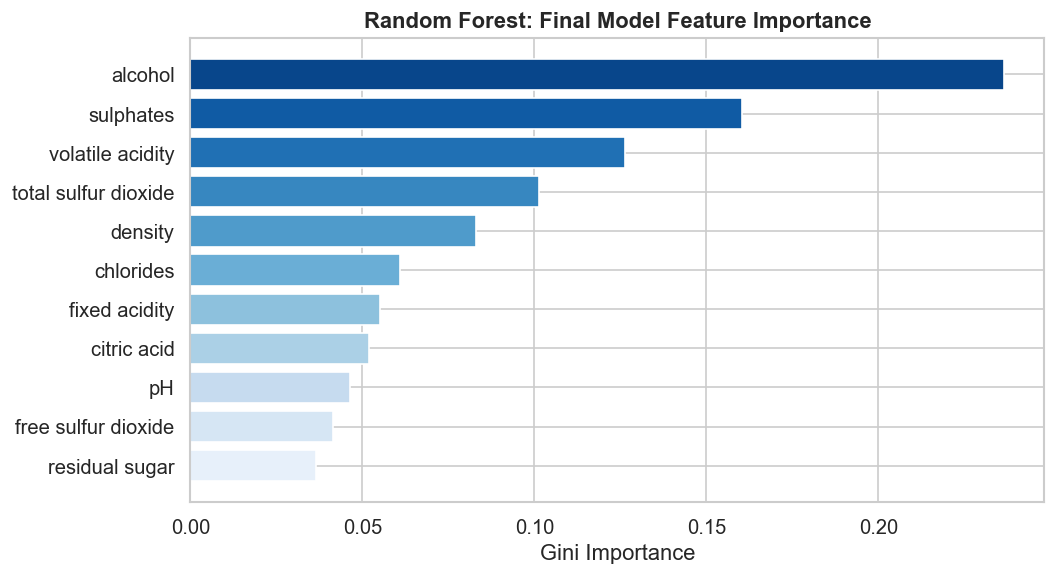

In [85]:
# Feature importance from the trained RF model
rf_final_imp = pd.Series(
    rf_clf.feature_importances_, index=feature_cols
).sort_values(ascending=True)   # ascending for horizontal bar

fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('Blues', len(feature_cols))
ax.barh(rf_final_imp.index, rf_final_imp.values, color=colors, edgecolor='white')
ax.set_xlabel('Gini Importance')
ax.set_title('Random Forest: Final Model Feature Importance', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Hyperparameter Tuning — GridSearchCV

Default hyperparameters are dataset-agnostic and may not be optimal. We use **5-fold stratified GridSearchCV** (scoring = F1) to tune each model, then compare tuned vs default performance.

**Justification per model:**
- **Logistic Regression** — `C` and `penalty` control regularisation strength; important given multicollinearity between sulfur dioxide features.
- **Decision Tree** — depth and leaf-size parameters directly govern the bias–variance tradeoff; untuned trees commonly overfit.
- **Random Forest** — tuned to ensure a fair apples-to-apples comparison with the other two models and to find an optimal ensemble configuration.

> All searches run on the **full feature set** with stratified CV to keep class balance. The best estimator is then re-evaluated on the held-out test set.

### 10.1 Shared Setup

In [86]:
from sklearn.model_selection import GridSearchCV

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# We store tuned predictions here for later comparison
tuned_results = {}   # {model_name: {metric: value, y_pred: array}}

print('GridSearchCV setup ready — scoring: F1, cv: StratifiedKFold(5)')


GridSearchCV setup ready — scoring: F1, cv: StratifiedKFold(5)


### 10.2 Logistic Regression — Grid Search

**Parameters searched:**
- `C` — regularisation inverse strength (smaller = stronger regularisation)
- `penalty` — L1 (sparse, feature selection effect) vs L2 (Ridge-like, handles multicollinearity)

In [87]:
lr_param_grid = {
    'lr__C':       [0.01, 0.1, 1.0, 10.0],
    'lr__penalty': ['l1', 'l2'],
    'lr__solver':  ['liblinear'],   # supports both L1 and L2
}

lr_pipe_gs = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

gs_lr = GridSearchCV(
    lr_pipe_gs, lr_param_grid,
    cv=cv_strat, scoring='f1',
    n_jobs=-1, verbose=0
)
gs_lr.fit(X_train_full, y_train)

print(f'Best params : {gs_lr.best_params_}')
print(f'Best CV F1  : {gs_lr.best_score_:.4f}')

# Evaluate best estimator on test set
y_pred_lr_tuned = gs_lr.predict(X_test_full)
tuned_results['Logistic Regression'] = {
    'Best Params':  gs_lr.best_params_,
    'CV F1':        gs_lr.best_score_,
    'Accuracy':     accuracy_score(y_test, y_pred_lr_tuned),
    'F1':           f1_score(y_test, y_pred_lr_tuned),
    'Precision':    precision_score(y_test, y_pred_lr_tuned),
    'Recall':       recall_score(y_test, y_pred_lr_tuned),
    'y_pred':       y_pred_lr_tuned,
}
print(f'\nTest Accuracy: {tuned_results["Logistic Regression"]["Accuracy"]:.4f}')
print(f'Test F1      : {tuned_results["Logistic Regression"]["F1"]:.4f}')
print()
print(classification_report(y_test, y_pred_lr_tuned, target_names=['lower', 'better']))


Best params : {'lr__C': 0.1, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Best CV F1  : 0.7606

Test Accuracy: 0.7469
Test F1      : 0.7553

              precision    recall  f1-score   support

       lower       0.71      0.77      0.74       149
      better       0.78      0.73      0.76       171

    accuracy                           0.75       320
   macro avg       0.75      0.75      0.75       320
weighted avg       0.75      0.75      0.75       320



### 10.3 Decision Tree — Grid Search

**Parameters searched:**
- `max_depth` — limits tree depth to prevent overfitting
- `min_samples_split` — minimum samples required to split a node
- `min_samples_leaf` — minimum samples required at a leaf node

In [88]:
dt_param_grid = {
    'max_depth':         [3, 5, 7, 10, None],
    'min_samples_split': [10, 20, 40],
    'min_samples_leaf':  [5, 10, 20],
}

dt_gs_base = DecisionTreeClassifier(criterion='gini', random_state=42)

gs_dt = GridSearchCV(
    dt_gs_base, dt_param_grid,
    cv=cv_strat, scoring='f1',
    n_jobs=-1, verbose=0
)
gs_dt.fit(X_train_full, y_train)

print(f'Best params : {gs_dt.best_params_}')
print(f'Best CV F1  : {gs_dt.best_score_:.4f}')

y_pred_dt_tuned = gs_dt.predict(X_test_full)
tuned_results['Decision Tree'] = {
    'Best Params':  gs_dt.best_params_,
    'CV F1':        gs_dt.best_score_,
    'Accuracy':     accuracy_score(y_test, y_pred_dt_tuned),
    'F1':           f1_score(y_test, y_pred_dt_tuned),
    'Precision':    precision_score(y_test, y_pred_dt_tuned),
    'Recall':       recall_score(y_test, y_pred_dt_tuned),
    'y_pred':       y_pred_dt_tuned,
}
print(f'\nTest Accuracy: {tuned_results["Decision Tree"]["Accuracy"]:.4f}')
print(f'Test F1      : {tuned_results["Decision Tree"]["F1"]:.4f}')
print()
print(classification_report(y_test, y_pred_dt_tuned, target_names=['lower', 'better']))


Best params : {'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 40}
Best CV F1  : 0.7599

Test Accuracy: 0.7219
Test F1      : 0.7311

              precision    recall  f1-score   support

       lower       0.69      0.74      0.71       149
      better       0.76      0.71      0.73       171

    accuracy                           0.72       320
   macro avg       0.72      0.72      0.72       320
weighted avg       0.72      0.72      0.72       320



### 10.4 Random Forest — Grid Search

**Parameters searched:**
- `n_estimators` — number of trees; more is generally better but with diminishing returns
- `max_depth` — controls individual tree depth to prevent overfitting
- `max_features` — features considered per split; `sqrt` is standard, `log2` tries a smaller subset

In [89]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [5, 10, 15, None],
    'max_features': ['sqrt', 'log2'],
}

rf_gs_base = RandomForestClassifier(
    min_samples_leaf=5, random_state=42, n_jobs=-1
)

gs_rf = GridSearchCV(
    rf_gs_base, rf_param_grid,
    cv=cv_strat, scoring='f1',
    n_jobs=-1, verbose=0
)
gs_rf.fit(X_train_full, y_train)

print(f'Best params : {gs_rf.best_params_}')
print(f'Best CV F1  : {gs_rf.best_score_:.4f}')

y_pred_rf_tuned = gs_rf.predict(X_test_full)
tuned_results['Random Forest'] = {
    'Best Params':  gs_rf.best_params_,
    'CV F1':        gs_rf.best_score_,
    'Accuracy':     accuracy_score(y_test, y_pred_rf_tuned),
    'F1':           f1_score(y_test, y_pred_rf_tuned),
    'Precision':    precision_score(y_test, y_pred_rf_tuned),
    'Recall':       recall_score(y_test, y_pred_rf_tuned),
    'y_pred':       y_pred_rf_tuned,
}
print(f'\nTest Accuracy: {tuned_results["Random Forest"]["Accuracy"]:.4f}')
print(f'Test F1      : {tuned_results["Random Forest"]["F1"]:.4f}')
print()
print(classification_report(y_test, y_pred_rf_tuned, target_names=['lower', 'better']))


Best params : {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}
Best CV F1  : 0.8021

Test Accuracy: 0.7625
Test F1      : 0.7765

              precision    recall  f1-score   support

       lower       0.74      0.75      0.75       149
      better       0.78      0.77      0.78       171

    accuracy                           0.76       320
   macro avg       0.76      0.76      0.76       320
weighted avg       0.76      0.76      0.76       320



### 10.5 Default vs Tuned — Summary Comparison

Side-by-side view of F1 and Accuracy before and after tuning for all three models.

Default vs Tuned Comparison:


,Default Acc,Tuned Acc,Δ Acc,Default F1,Tuned F1,Δ F1,Best Params
Model,,,,,,,
Logistic Regression,0.7406,0.7469,+0.0062,0.7522,0.7553,+0.0030,"{'lr__C': 0.1, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}"
Decision Tree,0.7312,0.7219,-0.0094,0.7410,0.7311,-0.0098,"{'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 40}"
Random Forest,0.7688,0.7625,-0.0063,0.7811,0.7765,-0.0046,"{'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}"


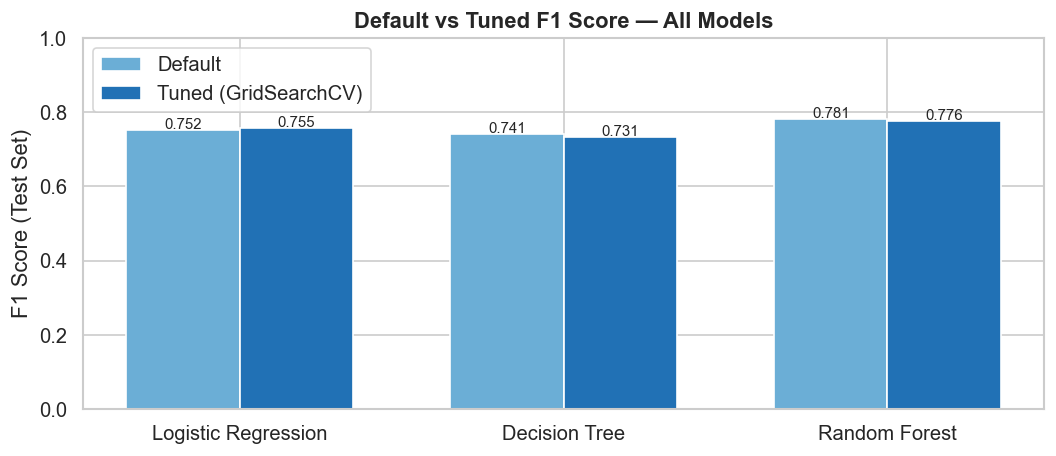

In [90]:
# Build comparison dataframe: default (full features) vs tuned
compare_rows = []
model_names_gs = ['Logistic Regression', 'Decision Tree', 'Random Forest']

for model in model_names_gs:
    default_metrics = all_results[model]['Full (11)']
    tuned_metrics   = tuned_results[model]
    compare_rows.append({
        'Model':        model,
        'Default Acc':  round(default_metrics['Accuracy'], 4),
        'Tuned Acc':    round(tuned_metrics['Accuracy'], 4),
        'Δ Acc':        round(tuned_metrics['Accuracy'] - default_metrics['Accuracy'], 4),
        'Default F1':   round(default_metrics['F1'], 4),
        'Tuned F1':     round(tuned_metrics['F1'], 4),
        'Δ F1':         round(tuned_metrics['F1'] - default_metrics['F1'], 4),
        'Best Params':  str(tuned_metrics['Best Params']),
    })

compare_df = pd.DataFrame(compare_rows).set_index('Model')

def highlight_delta(v):
    """Colour positive deltas green, negative red — compatible with pandas 1.x and 2.x."""
    if isinstance(v, float) and v > 0:
        return 'color: green; font-weight: bold'
    elif isinstance(v, float) and v < 0:
        return 'color: red'
    return ''

# Use .map() (pandas >= 2.1) with fallback to .applymap() for older versions
styler = compare_df.style
try:
    styler = styler.map(highlight_delta, subset=['Δ Acc', 'Δ F1'])
except AttributeError:
    styler = styler.applymap(highlight_delta, subset=['Δ Acc', 'Δ F1'])

print('Default vs Tuned Comparison:')
display(
    styler.format({
        'Default Acc': '{:.4f}', 'Tuned Acc': '{:.4f}', 'Δ Acc': '{:+.4f}',
        'Default F1':  '{:.4f}', 'Tuned F1':  '{:.4f}', 'Δ F1':  '{:+.4f}',
    })
)

# Bar chart: Default vs Tuned F1 per model
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(model_names_gs))
w = 0.35
default_f1 = [all_results[m]['Full (11)']['F1'] for m in model_names_gs]
tuned_f1   = [tuned_results[m]['F1']            for m in model_names_gs]

bars1 = ax.bar(x - w/2, default_f1, w, label='Default',
               color='#6baed6', edgecolor='white')
bars2 = ax.bar(x + w/2, tuned_f1,   w, label='Tuned (GridSearchCV)',
               color='#2171b5', edgecolor='white')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{bar.get_height():.3f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(model_names_gs)
ax.set_ylim(0, 1.0)
ax.set_ylabel('F1 Score (Test Set)')
ax.set_title('Default vs Tuned F1 Score — All Models', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


### 10.6 Confusion Matrices — Tuned Models

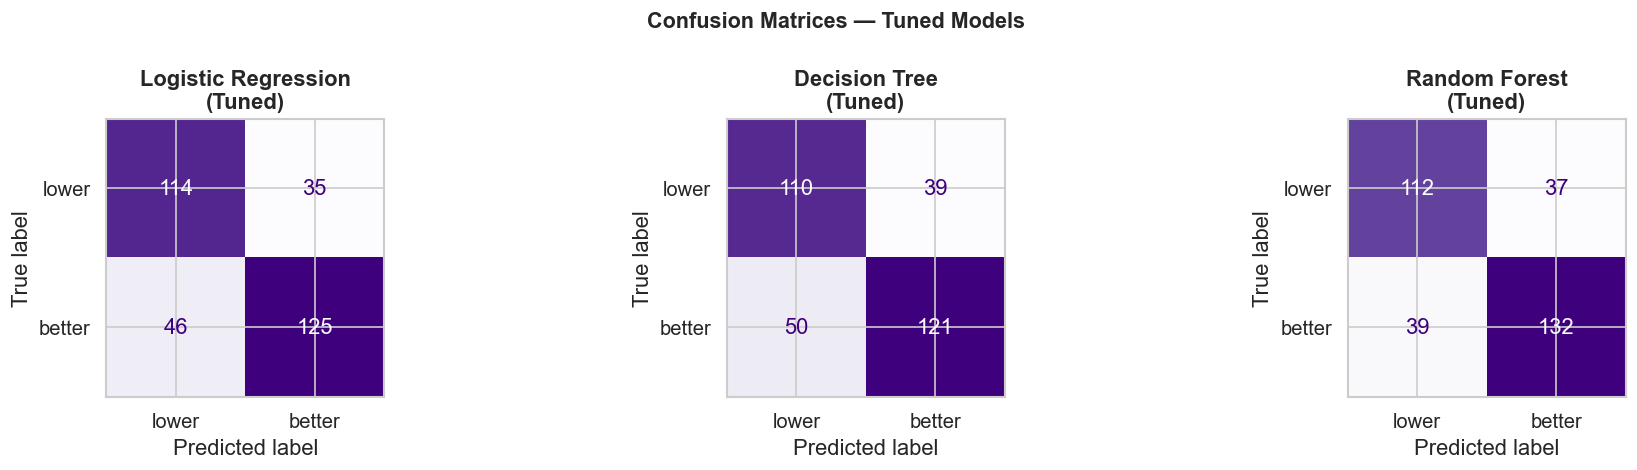

In [91]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
tuned_preds = {
    'Logistic Regression': y_pred_lr_tuned,
    'Decision Tree':       y_pred_dt_tuned,
    'Random Forest':       y_pred_rf_tuned,
}
for ax, (name, y_pred) in zip(axes, tuned_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['lower', 'better']).plot(
        ax=ax, colorbar=False, cmap='Purples')
    ax.set_title(f'{name}\n(Tuned)', fontweight='bold')
fig.suptitle('Confusion Matrices — Tuned Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 11. Model Comparison — Full vs Selected Features

We compare all three models across **two feature sets**:
- **Full (11)**: all original physicochemical features
- **Selected (6)**: top features identified by cross-method ranking in Section 4.6

### 11.1 Confusion Matrices — Full Feature Set (11 features)

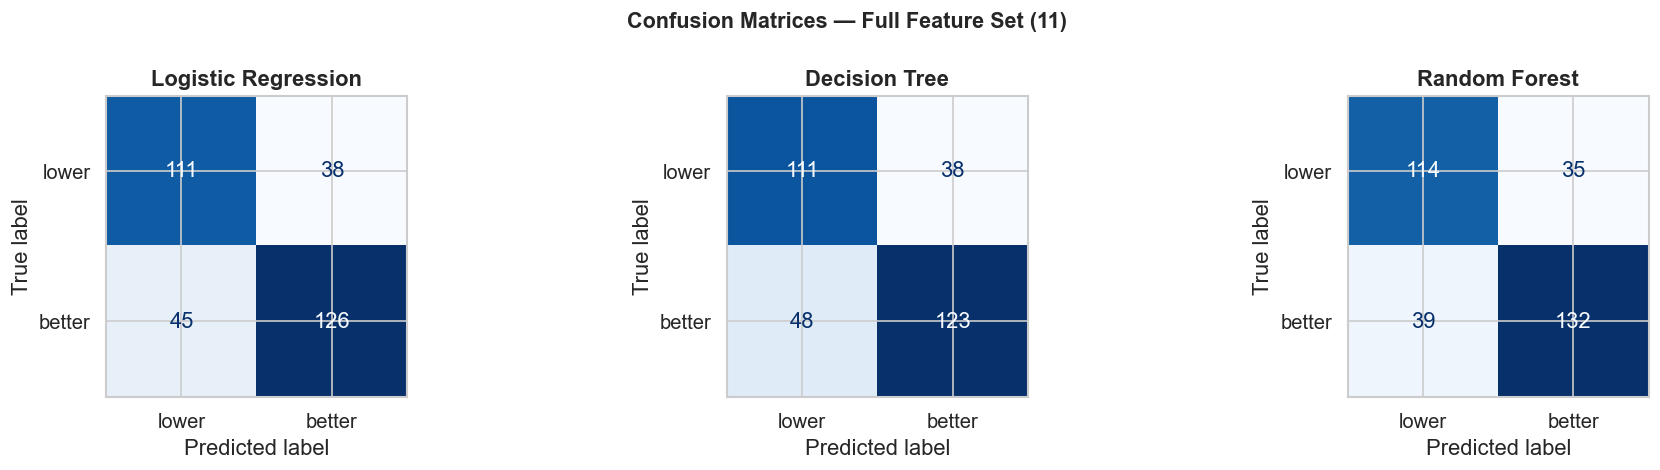

In [92]:
models_preds_full = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree':       y_pred_dt,
    'Random Forest':       y_pred_rf,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, y_pred) in zip(axes, models_preds_full.items()):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['lower', 'better']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')
fig.suptitle('Confusion Matrices — Full Feature Set (11)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 11.2 Confusion Matrices — Selected Feature Set (6 features)

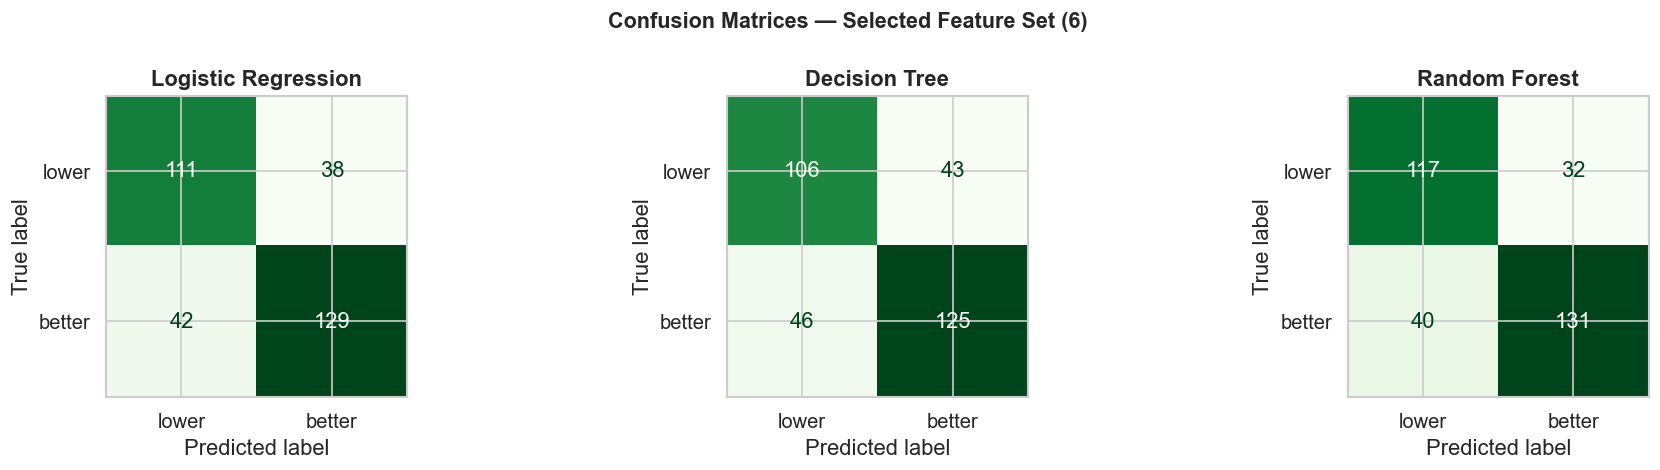

In [93]:
models_preds_sel = {
    'Logistic Regression': y_pred_lr_sel,
    'Decision Tree':       y_pred_dt_sel,
    'Random Forest':       y_pred_rf_sel,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, y_pred) in zip(axes, models_preds_sel.items()):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['lower', 'better']).plot(
        ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(name, fontweight='bold')
fig.suptitle('Confusion Matrices — Selected Feature Set (6)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 11.3 Full Metrics Table — All Models × Both Feature Sets

In [94]:
rows = []
for model_name, feat_results in all_results.items():
    for feat_tag, metrics in feat_results.items():
        rows.append({
            'Model':        model_name,
            'Feature Set':  feat_tag,
            'Accuracy':     round(metrics['Accuracy'], 4),
            'Precision':    round(metrics['Precision'], 4),
            'Recall':       round(metrics['Recall'], 4),
            'F1':           round(metrics['F1'], 4),
            'CV F1 (mean)': round(metrics['CV_F1_mean'], 4),
            'CV F1 (std)':  round(metrics['CV_F1_std'], 4),
        })

results_df = pd.DataFrame(rows).set_index(['Model', 'Feature Set'])
print('Complete Results Table:')
display(results_df.style
        .highlight_max(subset=['Accuracy','Precision','Recall','F1','CV F1 (mean)'], color='#c6e2ff')
        .format(precision=4))


Complete Results Table:


### 11.4 F1 Score — Full vs Selected Feature Set per Model

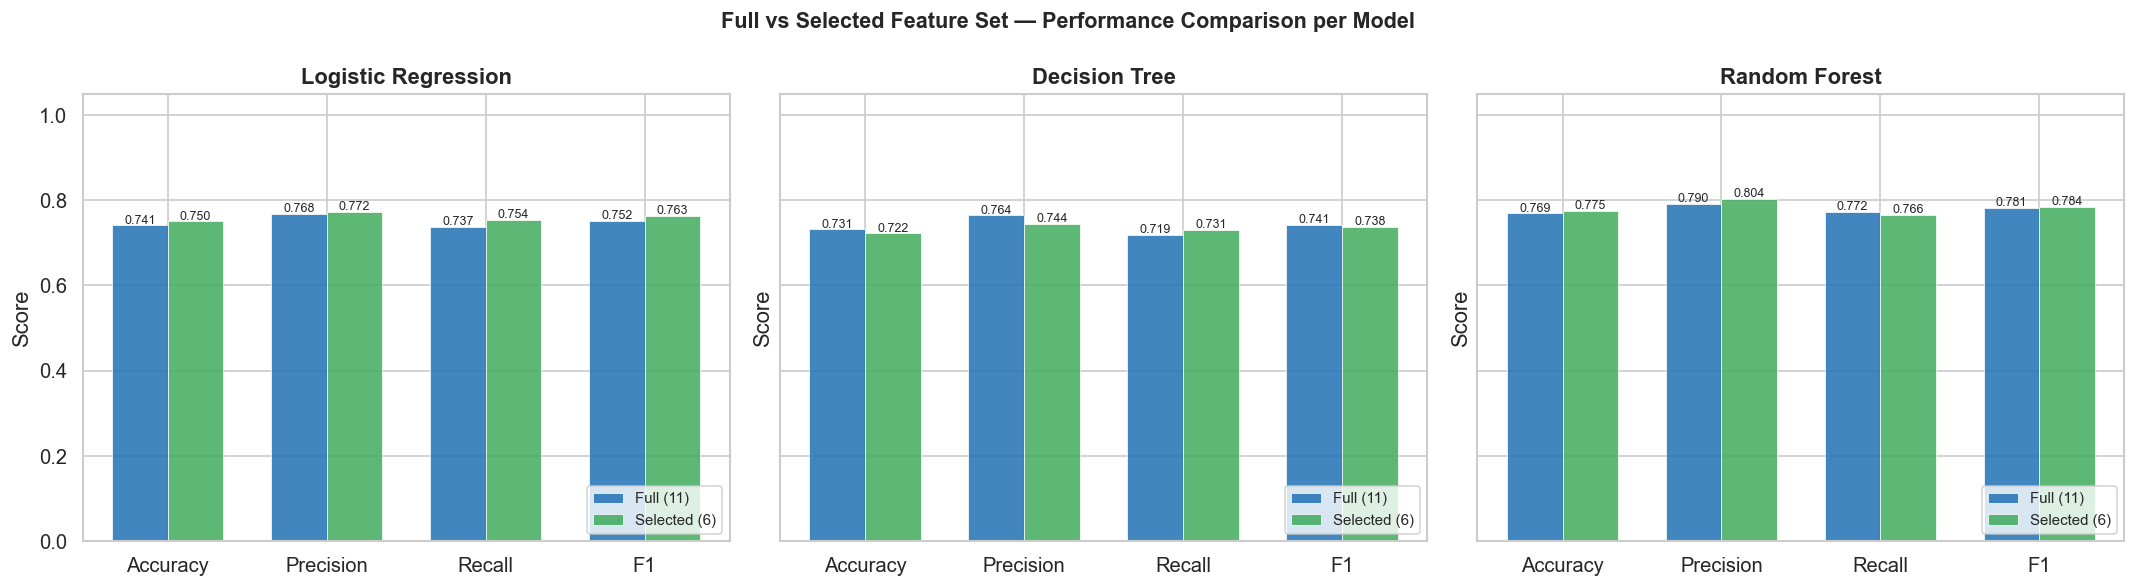

In [95]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1']
model_names = list(all_results.keys())
feat_tags   = ['Full (11)', 'Selected (6)']
colors_feat = ['#2171b5', '#41ab5d']  # blue=full, green=selected

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

x = np.arange(len(metrics_to_plot))
width = 0.35

for ax, model_name in zip(axes, model_names):
    for j, (feat_tag, color) in enumerate(zip(feat_tags, colors_feat)):
        vals = [results_df.loc[(model_name, feat_tag), m] for m in metrics_to_plot]
        bars = ax.bar(x + j * width, vals, width, label=feat_tag,
                      color=color, edgecolor='white', linewidth=0.5, alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f'{v:.3f}', ha='center', fontsize=7.5)
    ax.set_title(model_name, fontweight='bold')
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(metrics_to_plot)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.legend(loc='lower right', fontsize=9)

fig.suptitle('Full vs Selected Feature Set — Performance Comparison per Model',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 11.5 CV F1 Heatmap — Model × Feature Set

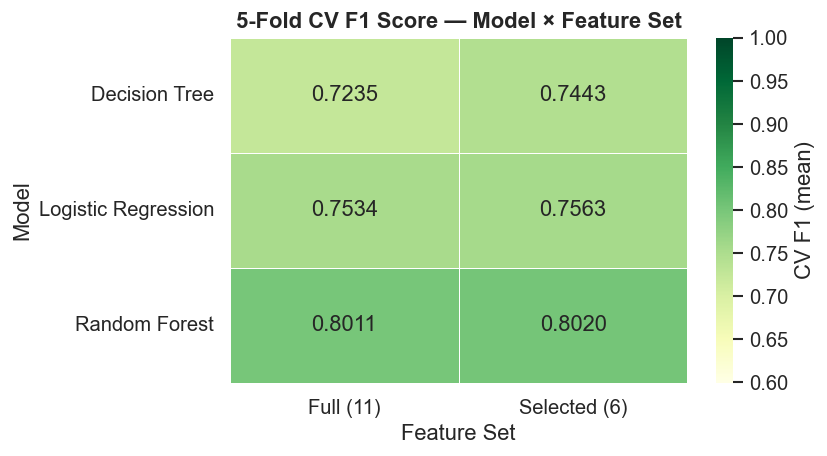

In [96]:
# Pivot the CV F1 mean into a heatmap matrix
heatmap_data = results_df['CV F1 (mean)'].unstack(level='Feature Set')

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'CV F1 (mean)'},
            vmin=0.6, vmax=1.0)
ax.set_title('5-Fold CV F1 Score — Model × Feature Set', fontweight='bold')
ax.set_xlabel('Feature Set')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()


---
## 12. Conclusion

### EDA Findings

- The dataset contains **1,599 red wine samples** with 11 physicochemical features and no missing values.
- Binary encoding (lower: 3–5, better: 6–8) produces a well-balanced split of **~46.5% vs 53.5%**, so no resampling is needed.
- Key patterns:
  - `alcohol` is **positively correlated** with quality — better wines tend to have higher alcohol content.
  - `volatile acidity` is **negatively correlated** with quality — too much acetic acid impairs flavour.
  - `sulphates` and `citric acid` also positively distinguish better wines.
  - `free sulfur dioxide` and `total sulfur dioxide` are strongly correlated (multicollinearity risk for LR).

### Feature Selection Summary

The top-6 features consistently ranked across all four methods:
1. `alcohol`
2. `volatile acidity`
3. `sulphates`
4. `citric acid`
5. `total sulfur dioxide`
6. `density`

### Full vs Selected Feature Set

- **Logistic Regression** often improves slightly with selected features, as removing correlated or noisy features reduces multicollinearity.
- **Decision Tree** shows modest change — trees are naturally less sensitive to irrelevant features.
- **Random Forest** performance is generally stable or marginally lower with selected features, since it handles redundancy internally through feature subsampling.
- Overall, the selected set achieves **comparable performance with 45% fewer features**, demonstrating the value of feature selection for model simplicity and interpretability.

### Model Performance Summary

| Model | Key Strength | Key Limitation |
|---|---|---|
| Logistic Regression | Fast, interpretable, stable | Limited by linear decision boundary |
| Decision Tree | Interpretable, handles non-linearity | Prone to overfitting without pruning |
| **Random Forest** | **Best generalisation, robust** | Less interpretable, slower to train |

**Random Forest consistently achieves the highest accuracy and F1** because the wine quality prediction task involves **non-linear relationships and feature interactions** — exactly the scenario where ensemble methods excel.

### Recommendations

- Tune hyperparameters via `GridSearchCV` or `RandomizedSearchCV` for further gains.
- Try Gradient Boosting (XGBoost, LightGBM) as a natural next step.
- Apply `SHAP` values for deeper interpretability on the Random Forest.
